In [1]:
import pandas as pd 
import numpy as np                                                                                              
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.preprocessing import OneHotEncoder

In [2]:
##Basic setting , read data, clean and convert date time
df = pd.read_csv('data.csv', header=1)
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()

In [3]:
df = df.sort_values(by=['Individual code', 'Date'])
df

,Year,Date,Month,Day of Week,Individual code,0,1,2,3,4,...,15,16,17,18,19,20,21,22,23,Daily total (Wh/d)
3178,2013,2013-09-06,9,Friday,F2013_10_B,0.0,5.0,3.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,18.0,44.0,15.0,87.0
3171,2013,2013-09-07,9,Saturday,F2013_10_B,0.0,5.0,9.0,16.0,28.0,...,0.0,0.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,104.0
3188,2013,2013-09-08,9,Sunday,F2013_10_B,1.0,0.0,0.0,13.0,11.0,...,0.0,1.0,0.0,0.0,0.0,6.0,4.0,0.0,0.0,55.0
3176,2013,2013-09-09,9,Monday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0
3185,2013,2013-09-10,9,Tuesday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,66.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,2019,2019-12-09,12,Monday,F2019_9_D,27.0,35.0,31.0,29.0,29.0,...,0.0,0.0,3.0,20.0,0.0,0.0,0.0,0.0,10.0,403.0
29439,2019,2019-12-10,12,Tuesday,F2019_9_D,44.0,36.0,31.0,32.0,33.0,...,12.0,4.0,0.0,0.0,1.0,0.0,0.0,31.0,31.0,398.0
29440,2019,2019-12-11,12,Wednesday,F2019_9_D,24.0,35.0,49.0,29.0,26.0,...,0.0,0.0,37.0,29.0,27.0,26.0,20.0,19.0,101.0,556.0
29441,2019,2019-12-12,12,Thursday,F2019_9_D,54.0,38.0,26.0,27.0,27.0,...,8.0,29.0,34.0,31.0,37.0,28.0,58.0,28.0,0.0,608.0


In [4]:
# Separate dataset by individual and create Lag1_hour difference features
from typing import List

hour_cols = [str(i) for i in range(24)]

# Ensure we work on a copy
df_filtered = df.copy()

# Initialize Lag1_* columns with NaN (explicit creation without values)
for h in hour_cols:
    df_filtered[f"Lag1_{h}"] = np.nan

# Compute differences per individual (no mixing between individuals).
# For hour m>0: Lag1_m = current_hour_m - current_hour_{m-1}
# For hour 0: Lag1_0 = current_hour_0 - previous_day_hour_23 (shifted).

def _compute_lag_diffs(group):
    group = group.sort_values('Date').copy()
    for i, h in enumerate(hour_cols):
        if i > 0:
            prev_col = hour_cols[i-1]
            group[f"Lag1_{h}"] = group[h].astype(float) - group[prev_col].astype(float)
        else:
            # previous day's hour 23 for hour 0
            prev_day_h23 = group[hour_cols[-1]].shift(1)
            group[f"Lag1_{h}"] = group[h].astype(float) - prev_day_h23.astype(float)
    return group

# Apply per-individual and preserve NaNs for the first day of each individual
df_filtered = df_filtered.groupby('Individual code', group_keys=False).apply(_compute_lag_diffs)

# The first day for each individual will have NaNs (no previous day) as required
# Lag1_Total as the sum of absolute values of Lag1_* columns for each row
lag1_hour_cols = [f"Lag1_{h}" for h in hour_cols]
df_filtered['Lag1_Total'] = df_filtered[lag1_hour_cols].abs().sum(axis=1)

df_filtered

C:\Users\Admin\AppData\Local\Temp\ipykernel_13932\2873376981.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df_filtered.groupby('Individual code', group_keys=False).apply(_compute_lag_diffs)


,Year,Date,Month,Day of Week,Individual code,0,1,2,3,4,...,Lag1_15,Lag1_16,Lag1_17,Lag1_18,Lag1_19,Lag1_20,Lag1_21,Lag1_22,Lag1_23,Lag1_Total
3178,2013,2013-09-06,9,Friday,F2013_10_B,0.0,5.0,3.0,0.0,0.0,...,0.0,0.0,0.0,2.0,-2.0,0.0,18.0,26.0,-29.0,87.0
3171,2013,2013-09-07,9,Saturday,F2013_10_B,0.0,5.0,9.0,16.0,28.0,...,0.0,0.0,0.0,0.0,5.0,-4.0,-1.0,0.0,0.0,97.0
3188,2013,2013-09-08,9,Sunday,F2013_10_B,1.0,0.0,0.0,13.0,11.0,...,0.0,1.0,-1.0,0.0,0.0,6.0,-2.0,-4.0,0.0,50.0
3176,2013,2013-09-09,9,Monday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0
3185,2013,2013-09-10,9,Tuesday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,2019,2019-12-09,12,Monday,F2019_9_D,27.0,35.0,31.0,29.0,29.0,...,0.0,0.0,3.0,17.0,-20.0,0.0,0.0,0.0,10.0,245.0
29439,2019,2019-12-10,12,Tuesday,F2019_9_D,44.0,36.0,31.0,32.0,33.0,...,4.0,-8.0,-4.0,0.0,1.0,-1.0,0.0,31.0,0.0,145.0
29440,2019,2019-12-11,12,Wednesday,F2019_9_D,24.0,35.0,49.0,29.0,26.0,...,0.0,0.0,37.0,-8.0,-2.0,-1.0,-6.0,-1.0,82.0,272.0
29441,2019,2019-12-12,12,Thursday,F2019_9_D,54.0,38.0,26.0,27.0,27.0,...,-13.0,21.0,5.0,-3.0,6.0,-9.0,30.0,-30.0,-28.0,277.0


In [5]:
from sklearn.preprocessing import LabelEncoder

df_filtered = df_filtered.dropna() # Drop NA rows (first day of each individual )
# Convert month and day of week to numerical values
df_filtered['Day of Week'] = pd.to_datetime(df_filtered['Date']).dt.dayofweek
df_filtered['Month'] = pd.to_datetime(df_filtered['Date']).dt.month

le = LabelEncoder()
df_filtered["Individual code"] = le.fit_transform(df_filtered["Individual code"]) # Convert Individual code to numerical values
df_filtered

C:\Users\Admin\AppData\Local\Temp\ipykernel_13932\2365507115.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Day of Week'] = pd.to_datetime(df_filtered['Date']).dt.dayofweek
C:\Users\Admin\AppData\Local\Temp\ipykernel_13932\2365507115.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Month'] = pd.to_datetime(df_filtered['Date']).dt.month
C:\Users\Admin\AppData\Local\Temp\ipykernel_13932\2365507115.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

,Year,Date,Month,Day of Week,Individual code,0,1,2,3,4,...,Lag1_15,Lag1_16,Lag1_17,Lag1_18,Lag1_19,Lag1_20,Lag1_21,Lag1_22,Lag1_23,Lag1_Total
3171,2013,2013-09-07,9,5,0,0.0,5.0,9.0,16.0,28.0,...,0.0,0.0,0.0,0.0,5.0,-4.0,-1.0,0.0,0.0,97.0
3188,2013,2013-09-08,9,6,0,1.0,0.0,0.0,13.0,11.0,...,0.0,1.0,-1.0,0.0,0.0,6.0,-2.0,-4.0,0.0,50.0
3176,2013,2013-09-09,9,0,0,0.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0
3185,2013,2013-09-10,9,1,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,87.0
3157,2013,2013-09-11,9,2,0,32.0,13.0,13.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,2019,2019-12-09,12,0,347,27.0,35.0,31.0,29.0,29.0,...,0.0,0.0,3.0,17.0,-20.0,0.0,0.0,0.0,10.0,245.0
29439,2019,2019-12-10,12,1,347,44.0,36.0,31.0,32.0,33.0,...,4.0,-8.0,-4.0,0.0,1.0,-1.0,0.0,31.0,0.0,145.0
29440,2019,2019-12-11,12,2,347,24.0,35.0,49.0,29.0,26.0,...,0.0,0.0,37.0,-8.0,-2.0,-1.0,-6.0,-1.0,82.0,272.0
29441,2019,2019-12-12,12,3,347,54.0,38.0,26.0,27.0,27.0,...,-13.0,21.0,5.0,-3.0,6.0,-9.0,30.0,-30.0,-28.0,277.0


In [6]:
# Define input features and target variable
X_cols = [f"Lag1_{i}" for i in hour_cols] + ["Lag1_Total","Year","Day of Week", "Month","Individual code"]
x = df_filtered[X_cols]

In [7]:
y = df_filtered[hour_cols]  # Predicting hourly consumption for the day

In [105]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Neural Network model 
import tensorflow as tf
import keras 
from tensorflow.python.keras.callbacks import EarlyStopping
from tensorflow.python.keras.layers.recurrent import LSTM
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Dense

In [115]:
train = df_filtered[df_filtered['Year'] <= 2016]
valid = df_filtered[df_filtered['Year'].isin([2017,2018])]
test = df_filtered[df_filtered['Year'] >= 2019]

In [116]:
x_train = train[X_cols] 
x_valid = valid[X_cols]
x_test = test[X_cols]

y_train = train[hour_cols]
y_valid = valid[hour_cols]
y_test = test[hour_cols]

In [ ]:
# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_valid = scaler.transform(x_valid)
# x_test = scaler.transform(x_test)

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=10, weights='')
knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

y_test_truetotal = y_test.sum(axis=1)
y_pred_truetotal = y_pred_knn.sum(axis=1)

error = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(error)
print(error)
print(rmse)
# print(np.sqrt(error))

# # Convert y_pred from numpy array to DataFrame with same columns and index as y_train
y_pred_knn_df = pd.DataFrame(y_pred_knn, columns=y_test.columns, index=y_test.index)
# print(y_pred_df)

# error_hourly = []

# for h in range(24):
#     mse = mean_squared_error(y_test[hour_cols[h]], y_pred_knn_df[hour_cols[h]])
#     error_hourly.append(mse)
#     # print(f"Hour {h}: MSE = {mse}, RMSE = {np.sqrt(mse)}")

1613.552778499652
40.169052496911746


In [336]:
# #Check ratio between standard deviation of hourly consumption and RMSE for each hour
# hourly_std = np.std(y_test, axis = 0)
# for h in range(24):
#     ratio = np.sqrt(error_hourly[h]) / hourly_std[h]
#     print(f"Hour {h}: Std = {hourly_std[h]}, RMSE = {np.sqrt(error_hourly[h])}, Ratio = {ratio}")

In [21]:
# Compute correlation between each hour and all Lag1 columns (including Lag1_Total)
# y_test: columns 0-23 (hours), x: Lag1_0 ... Lag1_23, Lag1_Total, etc.

# Select only Lag1 columns from x
lag1_cols = [col for col in x.columns if col.startswith("Lag1_")]
hour_cols = y_test.columns.astype(str).tolist()

# Concatenate y_test (hours) and x[lag1_cols] for correlation
corr_df = pd.concat([y_test, x[lag1_cols]], axis=1)

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Extract: hours (0-23) correlation with each other and with Lag1 columns
# Rows: hours (0-23), Columns: hours (0-23) + Lag1 columns
hour_and_lag1_corr = corr_matrix.loc[hour_cols, hour_cols + lag1_cols]

# Display the correlation dataframe
hour_and_lag1_corr['Lag1_Total']

0     0.447239
1     0.437007
2     0.417809
3     0.429301
4     0.417025
5     0.418674
6     0.460514
7     0.503337
8     0.490235
9     0.524936
10    0.524626
11    0.545617
12    0.556115
13    0.564335
14    0.549613
15    0.551246
16    0.564694
17    0.558974
18    0.552190
19    0.553235
20    0.575301
21    0.551035
22    0.478209
23    0.436507
Name: Lag1_Total, dtype: float64

In [26]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot MSE
    ax1.plot(history.history['mse'], label='Train MSE')
    ax1.plot(history.history['val_mse'], label='Val MSE')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('MSE')
    ax1.set_title('Mean Squared Error')
    ax1.legend()
    ax1.grid(True)

    # Plot MAE
    ax2.plot(history.history['mae'], label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('MAE')
    ax2.set_title('Mean Absolute Error')
    ax2.legend()
    ax1.grid(True)

    plt.show()

TRAINING USING NEURAL NETWORK

In [24]:
from tensorflow.python.keras.callbacks import EarlyStopping

In [106]:
n_feature = x_train.shape[1]
n_output = y_train.shape[1]

def train_model(x_train, y_train, x_valid, y_valid,
                num_nodes, dropout_prob, lr, batch_size, epochs):
    # Build model
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(n_feature,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(n_output)  # linear output layer (no activation)
    ])

    # Compile for regression
    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mse', 'mae'] 
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',       # what metric to watch
        patience=30,              # how many epochs to wait before stopping
        restore_best_weights=True # revert to best weights, not last
    )

    # Train
    history = nn_model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    best_nn_model_config = {
        'num_nodes': num_nodes,
        'dropout_prob': dropout_prob,
        'learning_rate': lr,
        'batch_size': batch_size,
        'epochs': epochs
    }
   
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_mae = history.history['mae'][-1]
    final_val_mae = history.history['val_mae'][-1]

    print(f"Final train loss (MSE): {final_train_loss:.4f}, MAE: {final_train_mae:.4f}")
    print(f"Final val loss (MSE): {final_val_loss:.4f}, MAE: {final_val_mae:.4f}")

    return nn_model, history

In [ ]:
least_val_loss = float('inf')
least_loss_model = None
best_nn_model_config = None
epochs = 150  

for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.01, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"{num_nodes} nodes | dropout: {dropout_prob} | lr: {lr} | batch size: {batch_size}")
                model, history = train_model(
                    x_train, y_train,
                    x_valid, y_valid,
                    num_nodes, dropout_prob, lr, batch_size, epochs
                )

                plot_history(history)
                val_loss = model.evaluate(x_valid, y_valid, verbose=0)[0]
                print(f"Validation Loss = {val_loss:.4f}")

                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model
                    print(f"least val_loss = {least_val_loss:.4f}")
                    best_nn_model_config = {
                        'num_nodes': num_nodes,
                        'dropout_prob': dropout_prob,
                        'learning_rate': lr,
                        'batch_size': batch_size,
                        'epochs': epochs
                    }

                    print(f"New best_nn_model_config: {best_nn_model_config} config:{best_nn_model_config}")

16 nodes | dropout: 0 | lr: 0.01 | batch size: 32


KeyboardInterrupt: 

In [ ]:
results = []
# Use the best model found during the search
y_pred_nn = least_loss_model.predict(x_test)

# Calculate metrics         
mae = mean_absolute_error(y_test, y_pred_nn)
mse = mean_squared_error(y_test, y_pred_nn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2 = r2_score(y_test, y_pred_nn)

results.append(('Neural Network', mae, mse, rmse, r2, best_nn_model_config, best_nn_model_config))
print(f"Final NN Test RMSE: {rmse:.4f}")
print(f"Final NN Test R²: {r2:.4f}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step
Final NN Test RMSE: 25.6530
Final NN Test R²: 0.5810


In [39]:
y_pred_NN_df = pd.DataFrame(y_pred_nn, columns=y_test.columns, index=y_test.index) # Convert y_pred_nn to dataframe for easier comparision
y_pred_NN_result_df = pd.DataFrame(results, columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'Best Params', 'Config'])

NameError: name 'results' is not defined

SAVE NEURAL NETWORK MODEL WITHOUT OVERSAMPLING

In [ ]:
import json
least_loss_model.save("best_nn_model.keras")

with open("best_nn_model_config.json", "w") as f:
    json.dump(best_nn_model_config, f, indent = 4)

Load Model

In [71]:
import tensorflow as tf
import json

# Load Model 
least_loss_model = tf.keras.models.load_model('best_nn_model.keras')

# Load config
with open('best_nn_model_config.json', 'r') as f:
    cfg = json.load(f)

print(cfg)

{'num_nodes': 64, 'dropout_prob': 0, 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 150}


In [201]:
y_pred_nn = least_loss_model.predict(x_test) # PREDICT ON UNTRAINED DATA
best_nn_model_config = cfg
y_pred_nn_TRAINED = least_loss_model.predict(x_train) # PREDICT ON TRAINED DATA

nn_results = []

# mae_trained = mean_absolute_error(y_train, y_pred_nn_TRAINED)
# mse_trained = mean_squared_error(y_train, y_pred_nn_TRAINED)
# rmse_trained = np.sqrt(mse_trained)
# r2_trained = r2_score(y_train, y_pred_nn_TRAINED)

# print(mae_trained, mse_trained, rmse_trained, r2_trained)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_nn)
mse = mean_squared_error(y_test, y_pred_nn) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_nn)

print(mae,mse,rmse,r2)

nn_results.append(('Loaded Neural Network', mae, mse, rmse, r2, best_nn_model_config, best_nn_model_config))

nn_results_df = pd.DataFrame(nn_results, columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'Best Params', 'Config'])

533/533 [==============================] - 1s 1ms/step
22.24381446838379 812.68505859375 28.507631585134355 0.47751522064208984


In [ ]:
#CONVERT RESULTS INTO DATAFRAME FOR BETTER VISUALISATION

y_pred_NN_df = pd.DataFrame(y_pred_nn, columns=y_test.columns, index=y_test.index) # Convert y_pred_nn to dataframe for easier comparision
y_pred_NN_result_df = pd.DataFrame(nn_results, columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'Best Params', 'Config'])
y_pred_NN_TRAINED_df = pd.DataFrame(y_pred_nn_TRAINED, columns=y_train.columns, index=y_train.index)

y_pred_NN_result_df

,Model,MAE,MSE,RMSE,R2,Best Params,Config
0,Loaded Neural Network,22.243814,812.685059,28.507632,0.477515,"{'num_nodes': 64, 'dropout_prob': 0, 'learning...","{'num_nodes': 64, 'dropout_prob': 0, 'learning..."


Comparison Between Untrained Data and Trained Data

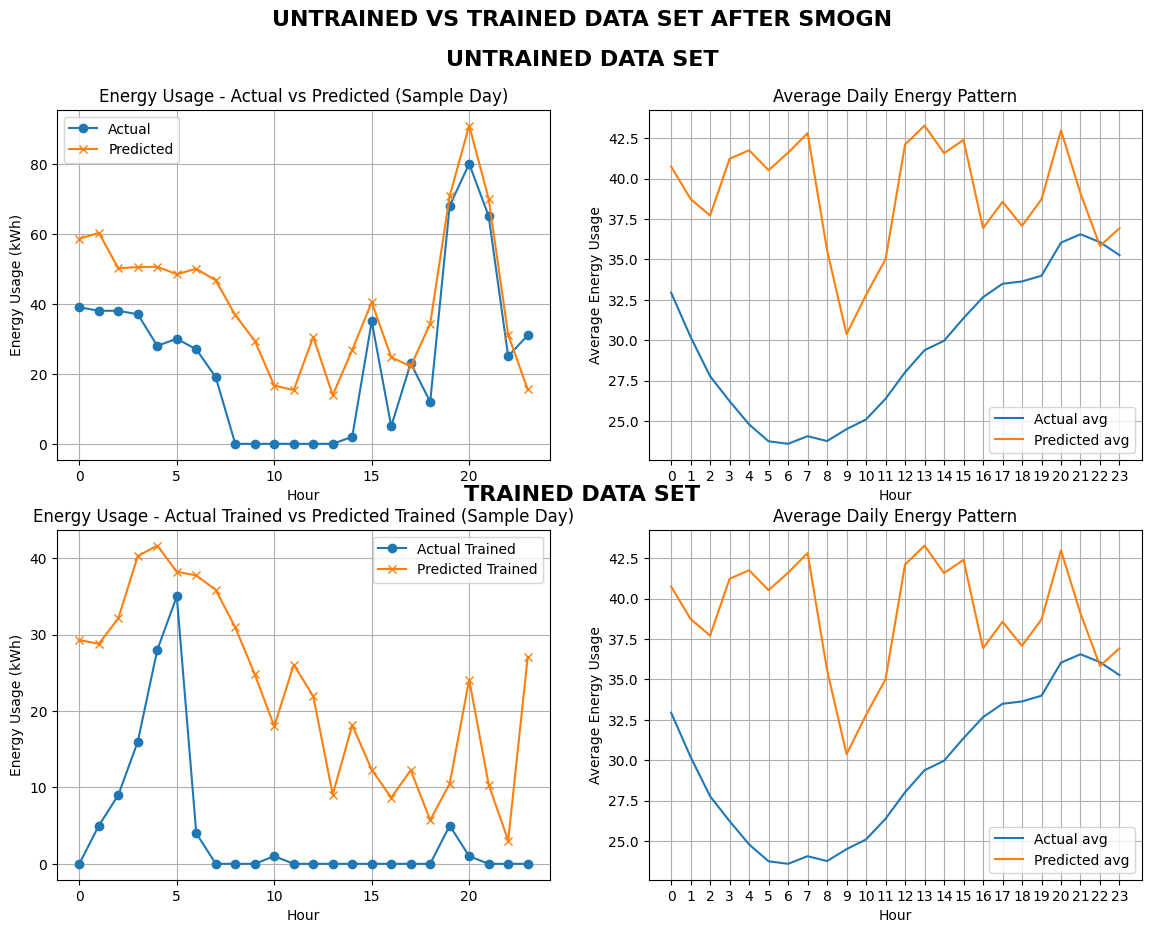

In [180]:
# UNTRAINED DATA SET
actual = y_test.iloc[i].values
predicted = y_pred_nn[i]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

i = 0
axes[0, 0].plot(range(24), actual, label='Actual', marker='o')
axes[0, 0].plot(range(24), predicted, label='Predicted', marker='x')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Energy Usage (kWh)')
axes[0, 0].set_title('Energy Usage - Actual vs Predicted (Sample Day)')
axes[0, 0].legend()
axes[0, 0].grid(True)
 

axes[0, 1].plot(np.mean(y_test, axis=0), label='Actual avg')
axes[0, 1].plot(np.mean(y_pred_nn, axis=0), label='Predicted avg')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Average Energy Usage')
axes[0, 1].legend()
axes[0, 1].set_title('Average Daily Energy Pattern')
axes[0, 1].grid(True)

# TRAINED DATA SET
actual_trained = y_train.iloc[i].values
predicted_trained = y_pred_nn_TRAINED[i]

axes[1, 0].plot(range(24), actual_trained, label='Actual Trained', marker='o')
axes[1, 0].plot(range(24), predicted_trained, label='Predicted Trained', marker='x')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Energy Usage (kWh)')
axes[1, 0].set_title('Energy Usage - Actual Trained vs Predicted Trained (Sample Day)')
axes[1, 0].legend()
axes[1, 0].grid(True)
 

axes[1, 1].plot(np.mean(y_test, axis=0), label='Actual avg')
axes[1, 1].plot(np.mean(y_pred_nn, axis=0), label='Predicted avg')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Average Energy Usage')
axes[1, 1].legend()
axes[1, 1].set_title('Average Daily Energy Pattern')
axes[1, 1].grid(True)


fig.suptitle('UNTRAINED VS TRAINED DATA SET AFTER SMOGN', fontsize=16, fontweight='bold')
fig.text(0.5, 0.93, 'UNTRAINED DATA SET', ha='center', va='center', fontsize=16, weight='bold')
fig.text(0.5, 0.495, 'TRAINED DATA SET', ha='center', va='center', fontsize=16, weight='bold')

plt.show()

In [181]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_split(name, model, X, Y, scale_y=None):
    # If you scaled y during training and kept a scaler, inverse_transform before metrics
    Y_pred = model.predict(X)
    if scale_y is not None:
        Y_true = scale_y.inverse_transform(Y)
        Y_pred = scale_y.inverse_transform(Y_pred)
    else:
        Y_true = Y

    rmse = np.sqrt(mean_squared_error(Y_true, Y_pred))
    mae  = mean_absolute_error(Y_true, Y_pred)
    print(f"{name}  RMSE: {rmse:.2f}  MAE: {mae:.2f}")
    return Y_true, Y_pred

# Examples: evaluate train/valid/test (replace variables with your actual arrays)
y_train_true, y_train_pred = evaluate_split("TRAIN", least_loss_model, x_train, y_train, scale_y=None)
y_valid_true, y_valid_pred = evaluate_split("VALID", least_loss_model, x_valid, y_valid, scale_y=None)
y_test_true,  y_test_pred  = evaluate_split("TEST",  least_loss_model, x_test,  y_test,  scale_y=None)

533/533 [==============================] - 1s 890us/step
TRAIN  RMSE: 30.40  MAE: 22.38
266/266 [==============================] - 0s 923us/step
VALID  RMSE: 39.68  MAE: 28.05
121/121 [==============================] - 0s 959us/step
TEST  RMSE: 28.51  MAE: 22.24


In [182]:
# If Pred mean > Train mean then underfit 

from IPython.display import display_html

# per-day total means
train_mean_actual = y_train_true.sum(axis=1).mean()
train_mean_pred   = y_train_pred.sum(axis=1).mean()

valid_mean_actual = y_valid_true.sum(axis=1).mean()
valid_mean_pred   = y_valid_pred.sum(axis=1).mean()

train_valid_df = pd.DataFrame(
    {
        "Train": [train_mean_actual, train_mean_pred],
        "Valid": [valid_mean_actual, valid_mean_pred],
    },
    index=["Actual mean (daily total)", "Pred mean (daily total)"],
)

# Hour-wise MAE
hour_mae = np.mean(np.abs(y_test_true.values - y_test_pred), axis=0)
hour_mae_df = pd.DataFrame({
    "Hour": [f"{h:02d}" for h in range(24)],
    "MAE": hour_mae
})

# Display side-by-side
left_html = train_valid_df.to_html()
right_html = hour_mae_df.to_html(index=False)
html = f"<div style='display:flex;align-items:flex-start;gap:40px'>{left_html}{right_html}</div>"
display_html(html, raw=True)

Train 
 Valid 
 
 
 
 
 Actual mean (daily total) 
 958.150103 
 958.129682 
 
 
 Pred mean (daily total) 
 970.375977 
 1074.744385 
 
 
 
 
 
 Hour 
 MAE 
 
 
 
 
 00 
 21.895236 
 
 
 01 
 21.172988 
 
 
 02 
 21.877809 
 
 
 03 
 24.314061 
 
 
 04 
 25.605138 
 
 
 05 
 24.929722 
 
 
 06 
 26.239378 
 
 
 07 
 27.604043 
 
 
 08 
 22.749175 
 
 
 09 
 20.344763 
 
 
 10 
 20.690168 
 
 
 11 
 21.950028 
 
 
 12 
 25.172589 
 
 
 13 
 23.661941 
 
 
 14 
 23.086265 
 
 
 15 
 23.016810 
 
 
 16 
 20.121719 
 
 
 17 
 20.726314 
 
 
 18 
 19.920752 
 
 
 19 
 20.204226 
 
 
 20 
 21.521818 
 
 
 21 
 19.411188 
 
 
 22 
 18.149805 
 
 
 23 
 19.485672

FIXING IMBALANCE DATA

In [ ]:
def train_model(x_train, y_train, x_valid, y_valid,
                num_nodes, dropout_prob, lr, batch_size, epochs):
    # ensure numpy arrays
    import numpy as _np
    x_train = x_train if isinstance(x_train, _np.ndarray) else getattr(x_train, "values", x_train)
    y_train = y_train if isinstance(y_train, _np.ndarray) else getattr(y_train, "values", y_train)
    x_valid = x_valid if isinstance(x_valid, _np.ndarray) else getattr(x_valid, "values", x_valid)
    y_valid = y_valid if isinstance(y_valid, _np.ndarray) else getattr(y_valid, "values", y_valid)

    # dynamic feature/output sizing (fixes mismatch when resampled changed columns)
    n_feature = x_train.shape[1]
    n_output = y_train.shape[1]

    if n_feature == 0:
        raise ValueError("x_train has zero columns. Check smogn_oversample output and df_smogn.columns printed earlier.")

    # Build model with dynamic sizes
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(n_feature,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(n_output)  # linear output
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mse', 'mae']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    history = nn_model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[],
        verbose=0
    )
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_mae = history.history['mae'][-1]
    final_val_mae = history.history['val_mae'][-1]

    print(f"Final train loss (MSE): {final_train_loss:.4f}, MAE: {final_train_mae:.4f}")
    print(f"Final val loss (MSE): {final_val_loss:.4f}, MAE: {final_val_mae:.4f}")

    return nn_model, history

In [ ]:
import pandas as pd
import numpy as np
import smogn

def smogn_oversample(x_train, y_train):
    # --- Convert inputs to DataFrames ---
    X_df = x_train.reset_index(drop=True).copy() if isinstance(x_train, pd.DataFrame) else pd.DataFrame(x_train, columns=[f"f{i}" for i in range(x_train.shape[1])])
    Y_df = y_train.reset_index(drop=True).copy() if isinstance(y_train, pd.DataFrame) else pd.DataFrame(y_train, columns=[f"y{i}" for i in range(y_train.shape[1])])

    orig_feat_cols = list(X_df.columns)
    orig_hour_cols = list(Y_df.columns)

    # scalar target for SMOGN
    Y_df["target"] = Y_df.sum(axis=1)
    df = pd.concat([X_df, Y_df], axis=1).reset_index(drop=True)

    df_smogn = smogn.smoter(
        data=df,
        y="target",
        k=5,                     # smooth synthetic neighbors
        pert=0.05,               # moderate perturbation
        rel_thres=0.8,           # only oversample truly extreme values
        rel_method="auto",
        rel_xtrm_type="high",    # only oversample high-energy tail
        samp_method="extreme"    # softer oversampling than "extreme"
    )

    # Debug
    print(f"df_smogn rows: {len(df)} -> {len(df_smogn)}")
    print("df_smogn.columns:", list(df_smogn.columns)[:200])

    df_smogn = df_smogn.reset_index(drop=True) 

    # Preferred: intersection of original feature names
    feat_cols = [c for c in orig_feat_cols if c in df_smogn.columns]

    # Fallbacks if nothing matched
    feat_cols = [c for c in orig_feat_cols if c in df_smogn.columns]
    if not feat_cols:
        exclude = set(orig_hour_cols + ["target"])
        candidates = [c for c in df_smogn.columns if c not in exclude]
        if len(candidates) >= len(orig_feat_cols):
            feat_cols = candidates[:len(orig_feat_cols)]
            print("Fallback feature cols:", feat_cols)
        else:
            numeric = [c for c in df_smogn.select_dtypes(include=[np.number]).columns if c not in exclude]
            feat_cols = numeric[:len(orig_feat_cols)]
            print("Fallback numeric cols:", feat_cols)

    x_resampled_df = df_smogn[feat_cols].copy()

    # Targets: prefer original hour names, else try numeric or y* columns
    hour_cols = [c for c in orig_hour_cols if c in df_smogn.columns]
    if len(hour_cols) != len(orig_hour_cols):
        candidates = [c for c in df_smogn.columns if str(c).isdigit() or str(c).startswith("y")]
        hour_cols = candidates[:len(orig_hour_cols)]
        print("Adjusted hour columns to:", hour_cols)

    if len(hour_cols) != len(orig_hour_cols):
        print("ERROR: Resampled target width mismatch. df_smogn columns:", list(df_smogn.columns))
        raise AssertionError("Resampled target width mismatch")

    y_resampled_df = df_smogn[hour_cols].copy()
    y_resampled_df.columns = orig_hour_cols

    print(f"SMOGN: original rows {len(X_df)} -> resampled rows {len(x_resampled_df)}; features={len(feat_cols)} targets={y_resampled_df.shape[1]}")
    return x_resampled_df, y_resampled_df

# --- run oversampling ONCE before your hyperparameter loop ---
x_train_res_df, y_train_res_df = smogn_oversample(x_train, y_train)
print("Resampled shapes:", getattr(x_train_res_df, "shape", None), getattr(y_train_res_df, "shape", None))
assert x_train_res_df.shape[1] > 0, "Resampled X has zero columns"
assert y_train_res_df.shape[1] == y_train.shape[1], "Resampled Y width != original Y width"

r_index: 100%|##########| 488/488 [00:02<00:00, 191.90it/s]


df_smogn rows: 17055 -> 15715
df_smogn.columns: ['Lag1_0', 'Lag1_1', 'Lag1_2', 'Lag1_3', 'Lag1_4', 'Lag1_5', 'Lag1_6', 'Lag1_7', 'Lag1_8', 'Lag1_9', 'Lag1_10', 'Lag1_11', 'Lag1_12', 'Lag1_13', 'Lag1_14', 'Lag1_15', 'Lag1_16', 'Lag1_17', 'Lag1_18', 'Lag1_19', 'Lag1_20', 'Lag1_21', 'Lag1_22', 'Lag1_23', 'Lag1_Total', 'Year', 'Day of Week', 'Month', 'Individual code', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', 'target']
SMOGN: original rows 17055 -> resampled rows 15715; features=29 targets=24
Resampled shapes: (15715, 29) (15715, 24)


16 nodes | dropout: 0 | lr: 0.01 | batch size: 32
Final train loss (MSE): 1784.1993, MAE: 31.2491
Final val loss (MSE): 2274.1978, MAE: 35.2433


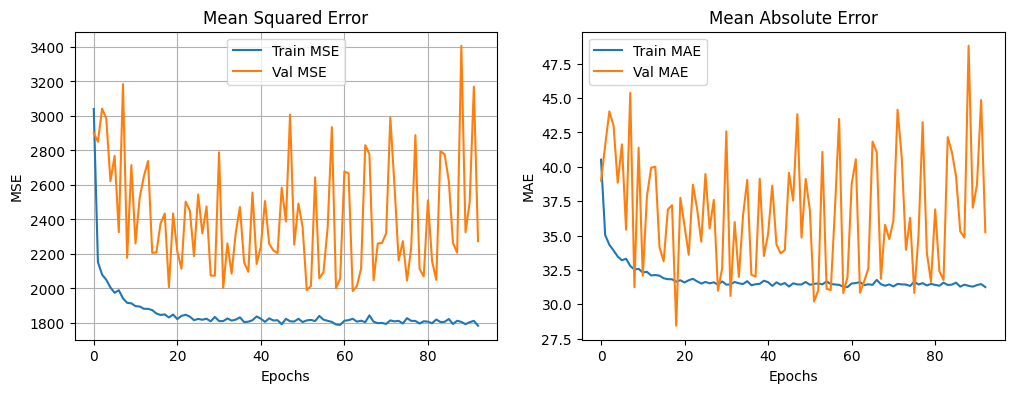

Validation Loss = 1984.9587
least val_loss = 1984.9587
New best_nn_model_config: {'num_nodes': 16, 'dropout_prob': 0, 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 150}
16 nodes | dropout: 0 | lr: 0.01 | batch size: 64
Final train loss (MSE): 1648.9188, MAE: 30.0765
Final val loss (MSE): 2120.9722, MAE: 34.6591


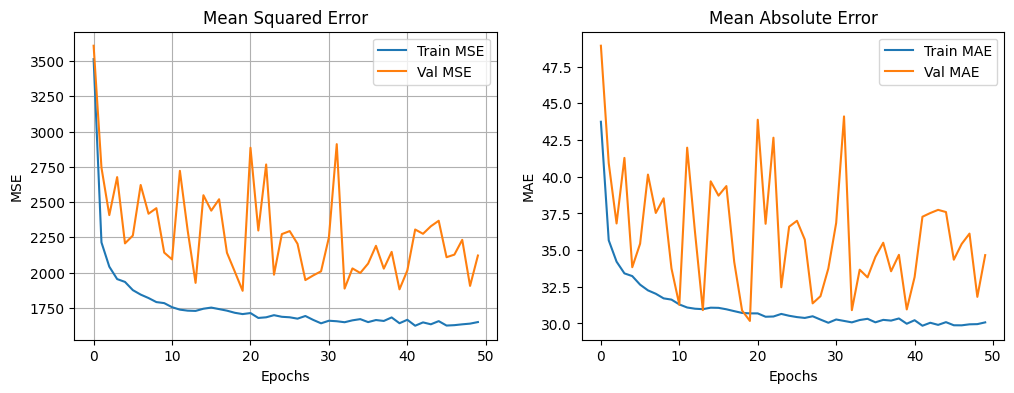

Validation Loss = 1870.5912
least val_loss = 1870.5912
New best_nn_model_config: {'num_nodes': 16, 'dropout_prob': 0, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 150}
16 nodes | dropout: 0 | lr: 0.01 | batch size: 128
Final train loss (MSE): 1597.1312, MAE: 29.7097
Final val loss (MSE): 2010.3192, MAE: 33.3067


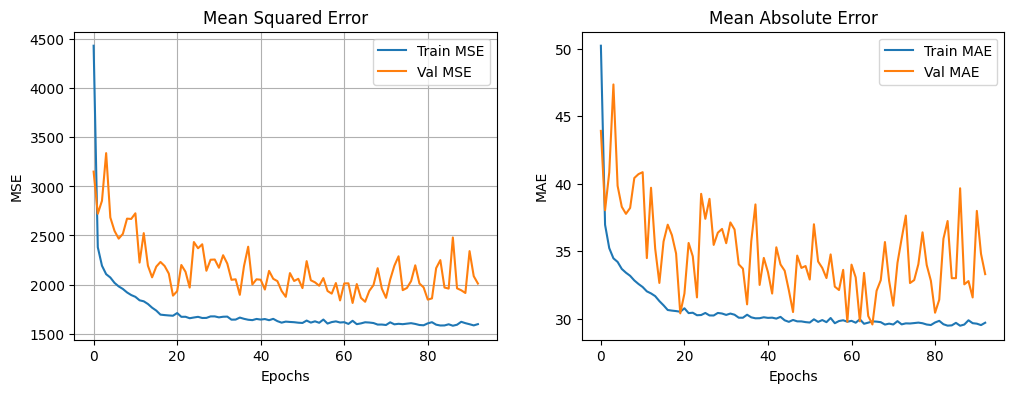

Validation Loss = 1812.6711
least val_loss = 1812.6711
New best_nn_model_config: {'num_nodes': 16, 'dropout_prob': 0, 'learning_rate': 0.01, 'batch_size': 128, 'epochs': 150}
16 nodes | dropout: 0 | lr: 0.005 | batch size: 32
Final train loss (MSE): 1573.9319, MAE: 29.4083
Final val loss (MSE): 1989.4716, MAE: 31.8415


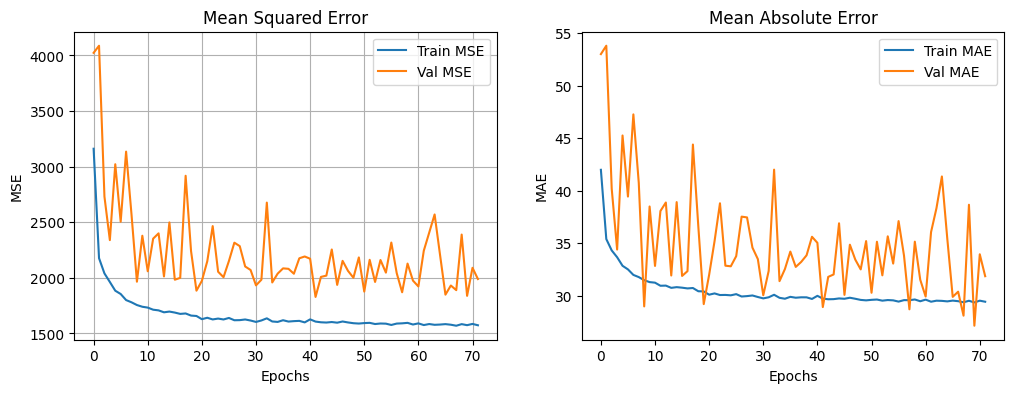

Validation Loss = 1828.4492
16 nodes | dropout: 0 | lr: 0.005 | batch size: 64
Final train loss (MSE): 1684.9948, MAE: 30.4145
Final val loss (MSE): 2076.3887, MAE: 32.0112


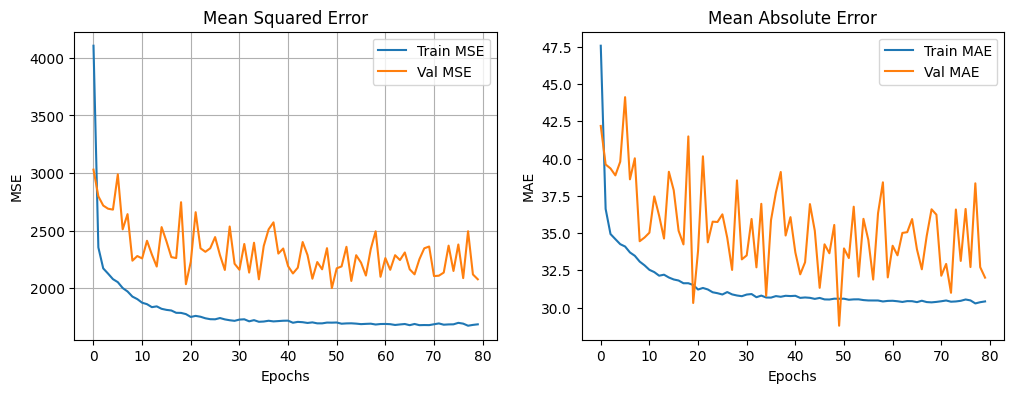

Validation Loss = 1999.8254
16 nodes | dropout: 0 | lr: 0.005 | batch size: 128
Final train loss (MSE): 1678.4144, MAE: 30.4277
Final val loss (MSE): 1984.5873, MAE: 31.7932


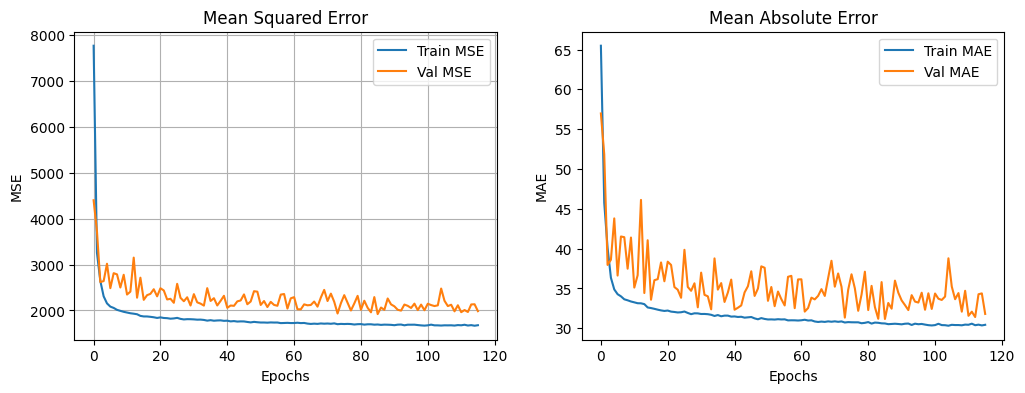

Validation Loss = 1920.8101
16 nodes | dropout: 0 | lr: 0.001 | batch size: 32
Final train loss (MSE): 1486.2278, MAE: 28.5025
Final val loss (MSE): 2048.7317, MAE: 34.1721


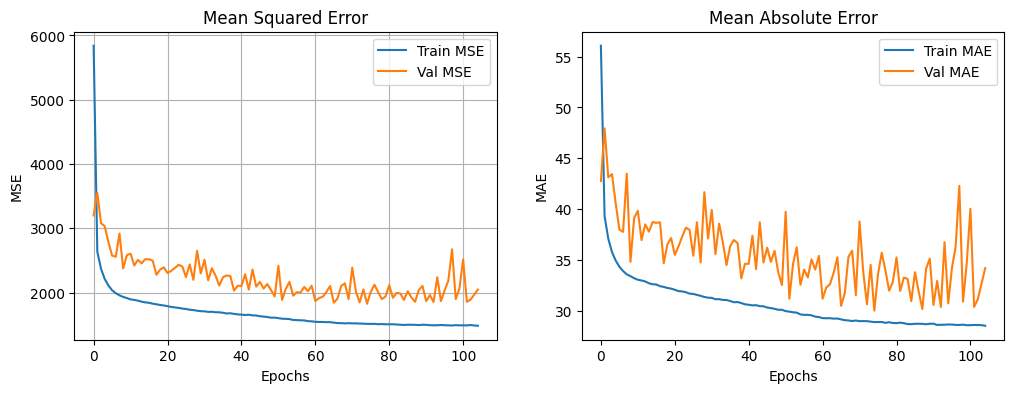

Validation Loss = 1827.7426
16 nodes | dropout: 0 | lr: 0.001 | batch size: 64
Final train loss (MSE): 1469.8845, MAE: 28.4452
Final val loss (MSE): 1882.7538, MAE: 31.1734


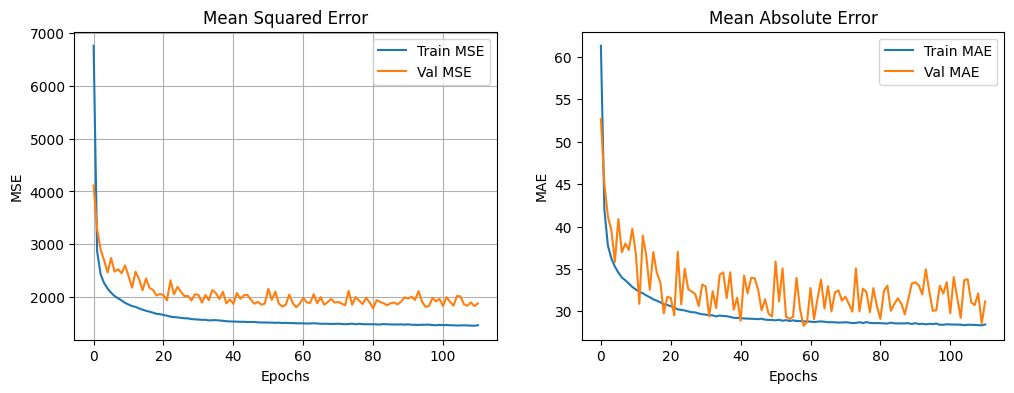

Validation Loss = 1788.4806
least val_loss = 1788.4806
New best_nn_model_config: {'num_nodes': 16, 'dropout_prob': 0, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 150}
16 nodes | dropout: 0 | lr: 0.001 | batch size: 128
Final train loss (MSE): 1735.3660, MAE: 31.2363
Final val loss (MSE): 2348.8059, MAE: 36.2573


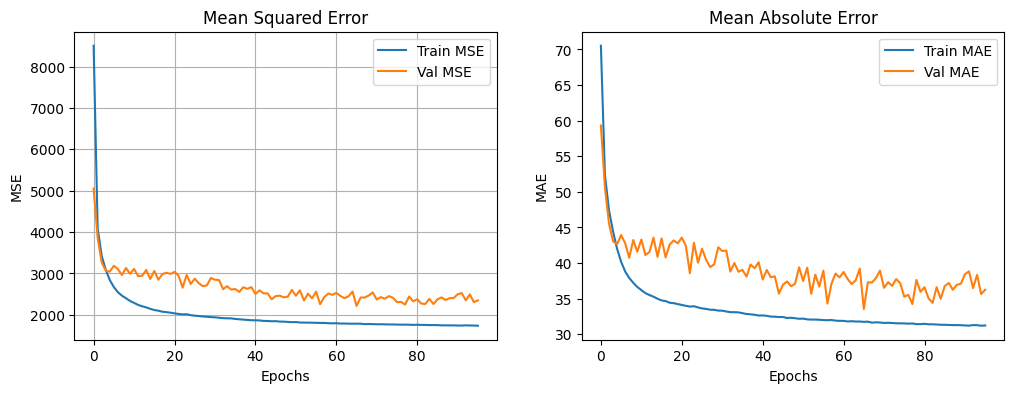

Validation Loss = 2213.2708
16 nodes | dropout: 0.2 | lr: 0.01 | batch size: 32
Final train loss (MSE): 2719.1936, MAE: 39.9937
Final val loss (MSE): 2514.6221, MAE: 38.6518


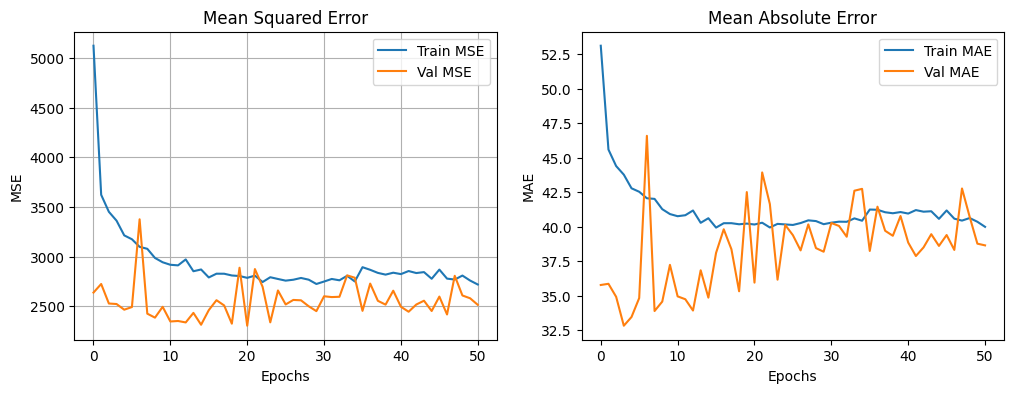

Validation Loss = 2304.4421
16 nodes | dropout: 0.2 | lr: 0.01 | batch size: 64
Final train loss (MSE): 2644.2798, MAE: 39.3790
Final val loss (MSE): 2390.6648, MAE: 37.2368


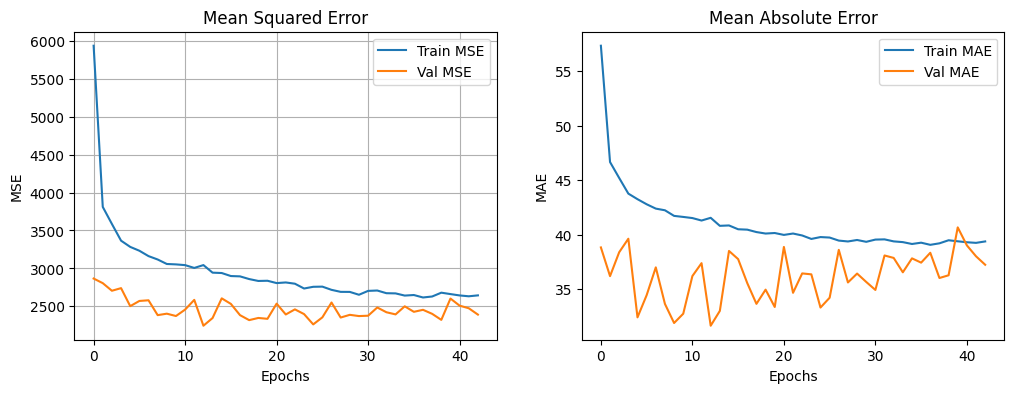

Validation Loss = 2244.0803
16 nodes | dropout: 0.2 | lr: 0.01 | batch size: 128
Final train loss (MSE): 2563.4688, MAE: 37.6866
Final val loss (MSE): 2241.4390, MAE: 34.2997


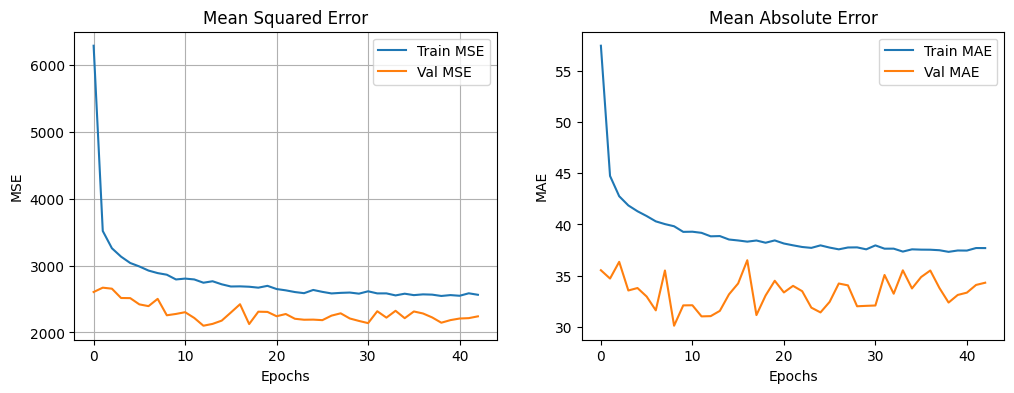

Validation Loss = 2101.2244
16 nodes | dropout: 0.2 | lr: 0.005 | batch size: 32
Final train loss (MSE): 2801.1147, MAE: 40.5257
Final val loss (MSE): 2728.9585, MAE: 40.8687


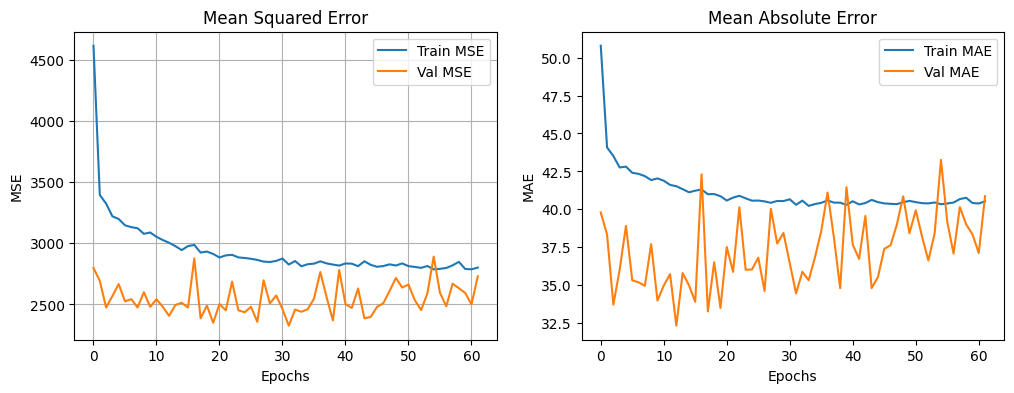

Validation Loss = 2326.1580
16 nodes | dropout: 0.2 | lr: 0.005 | batch size: 64
Final train loss (MSE): 2342.2700, MAE: 36.5349
Final val loss (MSE): 2344.6768, MAE: 36.6941


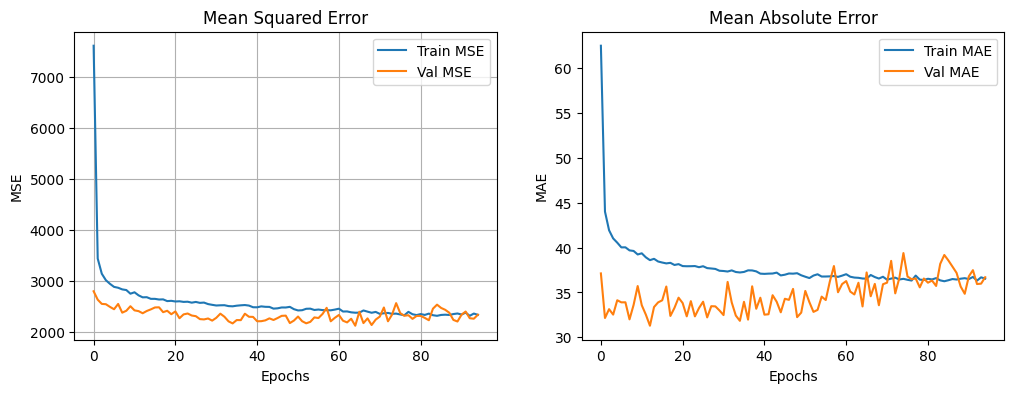

Validation Loss = 2129.1589
16 nodes | dropout: 0.2 | lr: 0.005 | batch size: 128
Final train loss (MSE): 2420.2893, MAE: 36.4941
Final val loss (MSE): 2182.1641, MAE: 34.8118


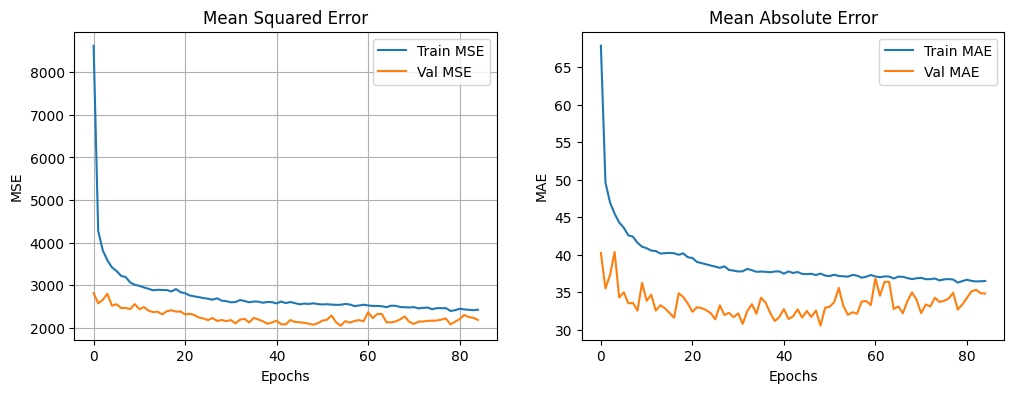

Validation Loss = 2045.4857
16 nodes | dropout: 0.2 | lr: 0.001 | batch size: 32
Final train loss (MSE): 2470.2510, MAE: 36.9739
Final val loss (MSE): 2169.6086, MAE: 33.3400


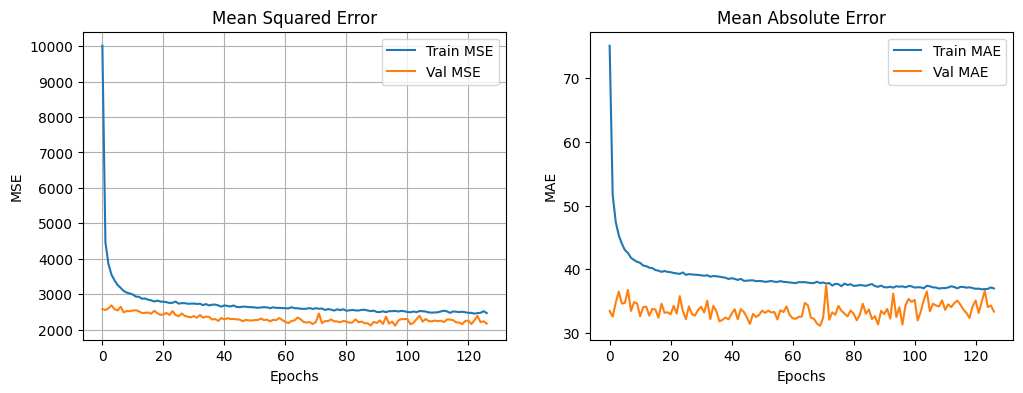

Validation Loss = 2112.0132
16 nodes | dropout: 0.2 | lr: 0.001 | batch size: 64
Final train loss (MSE): 2405.6775, MAE: 36.2829
Final val loss (MSE): 2173.8462, MAE: 32.4535


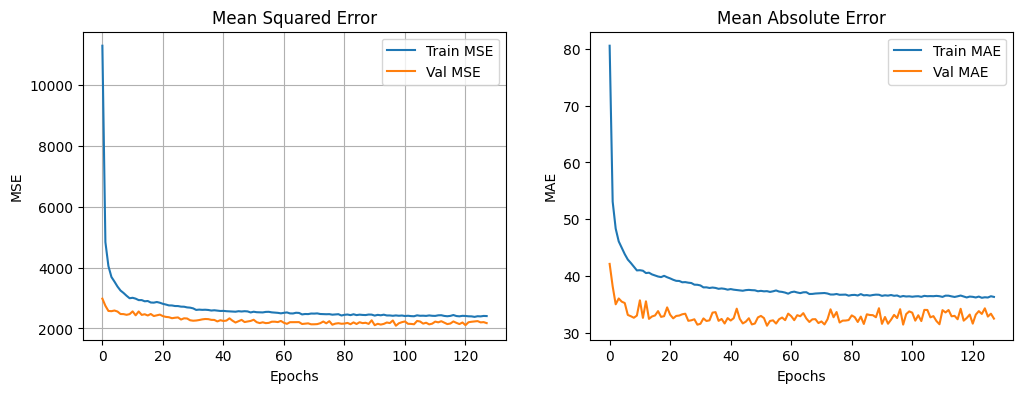

Validation Loss = 2087.8750
16 nodes | dropout: 0.2 | lr: 0.001 | batch size: 128
Final train loss (MSE): 2540.2566, MAE: 37.5602
Final val loss (MSE): 2385.3936, MAE: 32.7221


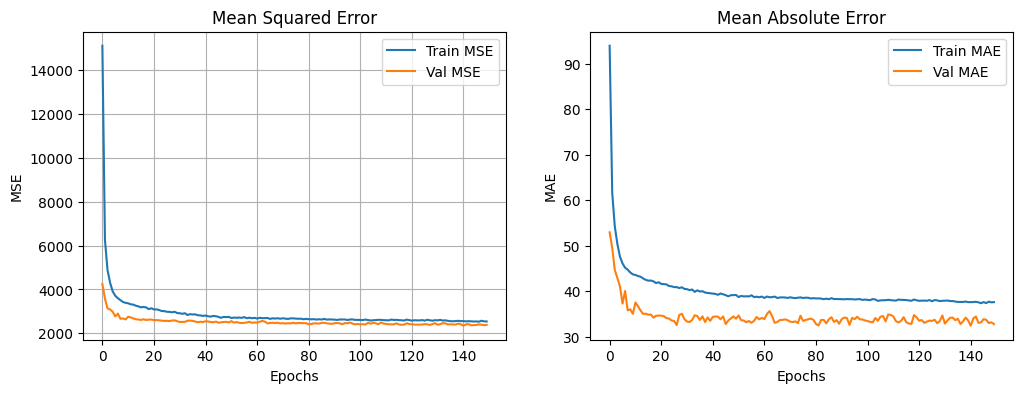

Validation Loss = 2385.3928
32 nodes | dropout: 0 | lr: 0.01 | batch size: 32
Final train loss (MSE): 1566.3899, MAE: 29.4200
Final val loss (MSE): 1814.2942, MAE: 30.3813


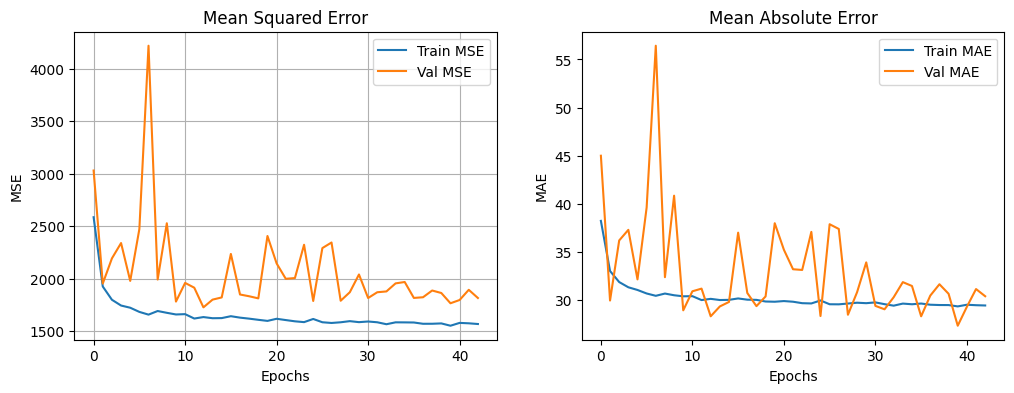

Validation Loss = 1725.2075
least val_loss = 1725.2075
New best_nn_model_config: {'num_nodes': 32, 'dropout_prob': 0, 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 150}
32 nodes | dropout: 0 | lr: 0.01 | batch size: 64
Final train loss (MSE): 1434.4185, MAE: 28.0289
Final val loss (MSE): 1946.2725, MAE: 33.3325


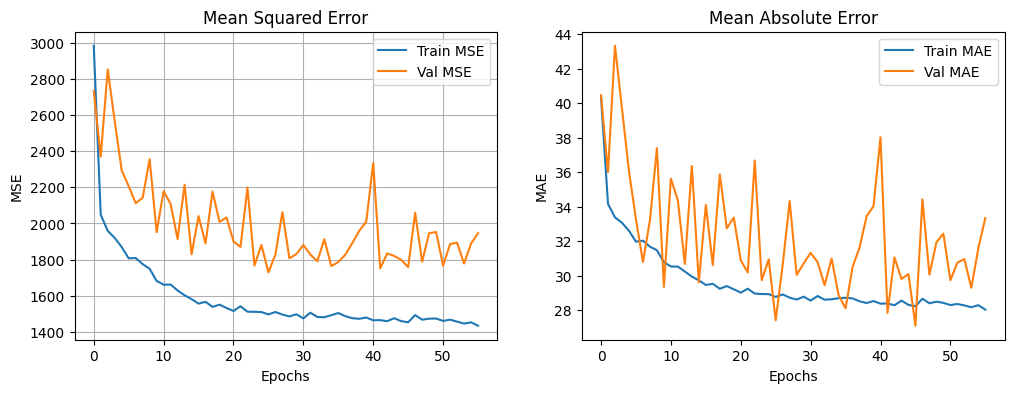

Validation Loss = 1729.3717
32 nodes | dropout: 0 | lr: 0.01 | batch size: 128
Final train loss (MSE): 1447.6202, MAE: 28.2610
Final val loss (MSE): 1954.3682, MAE: 28.6017


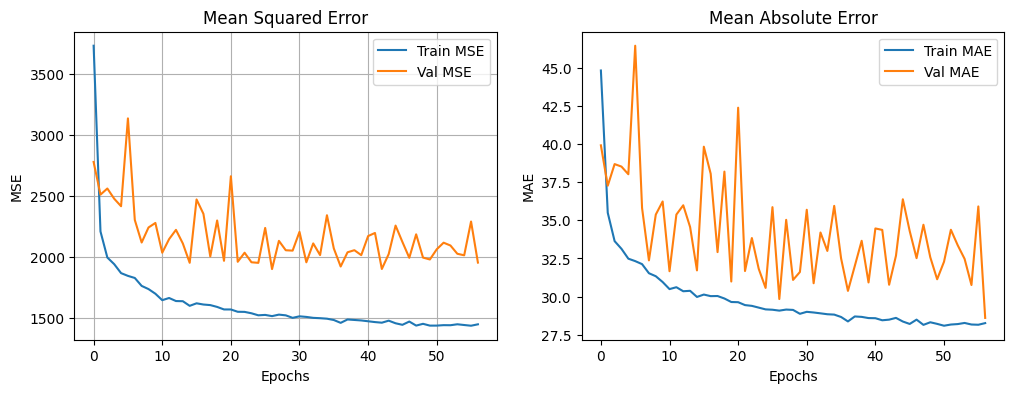

Validation Loss = 1901.0554
32 nodes | dropout: 0 | lr: 0.005 | batch size: 32
Final train loss (MSE): 1374.2059, MAE: 27.7578
Final val loss (MSE): 1930.7692, MAE: 32.0428


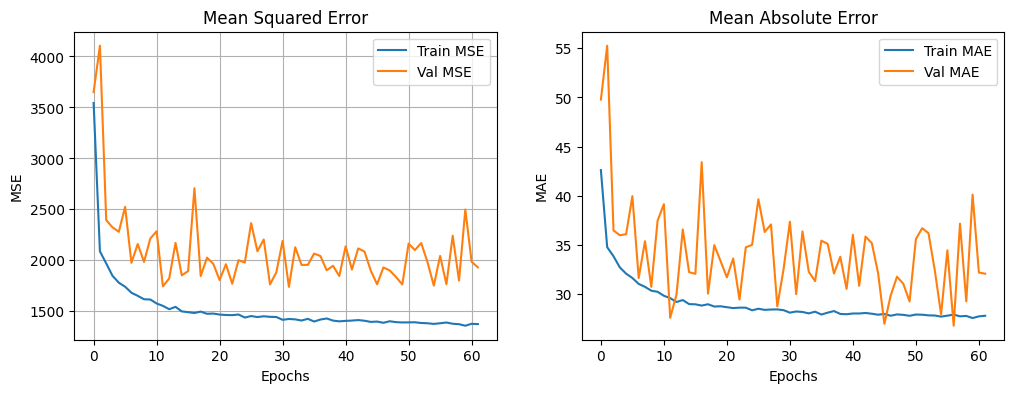

Validation Loss = 1739.4406
32 nodes | dropout: 0 | lr: 0.005 | batch size: 64
Final train loss (MSE): 1302.5151, MAE: 26.8332
Final val loss (MSE): 1883.6813, MAE: 30.8326


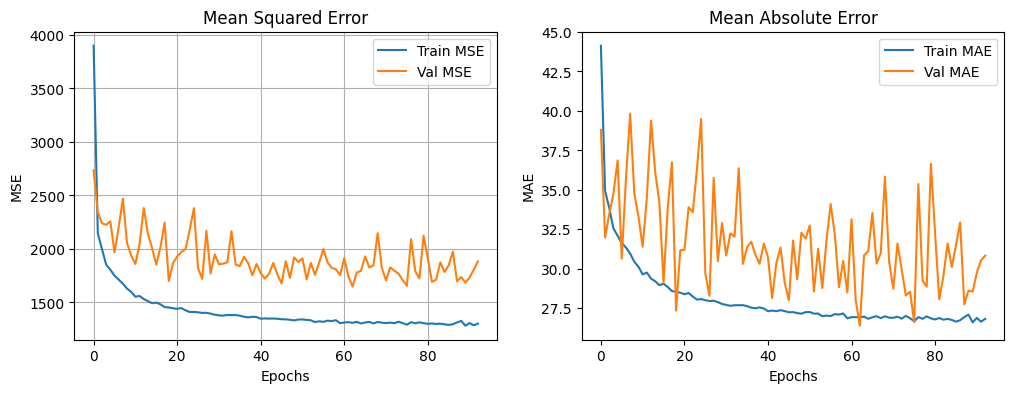

Validation Loss = 1648.3729
least val_loss = 1648.3729
New best_nn_model_config: {'num_nodes': 32, 'dropout_prob': 0, 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 150}
32 nodes | dropout: 0 | lr: 0.005 | batch size: 128
Final train loss (MSE): 1318.5085, MAE: 26.9808
Final val loss (MSE): 2009.8483, MAE: 34.1745


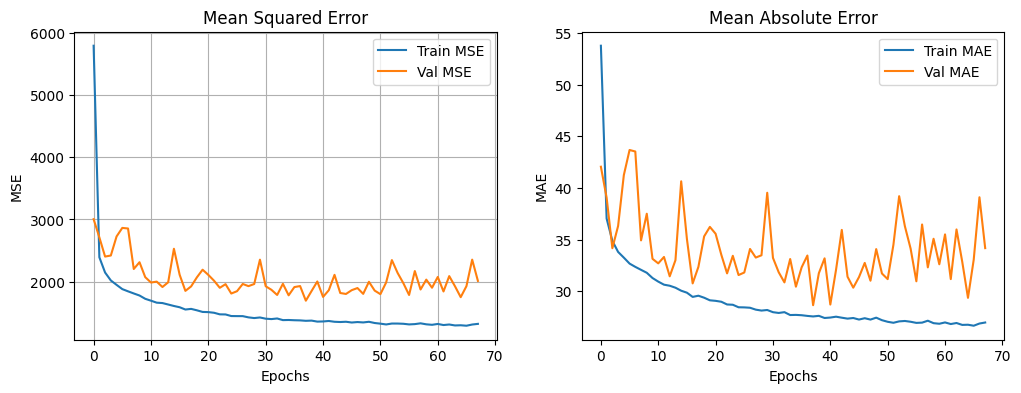

Validation Loss = 1691.7500
32 nodes | dropout: 0 | lr: 0.001 | batch size: 32
Final train loss (MSE): 1290.2031, MAE: 26.8951
Final val loss (MSE): 1849.4418, MAE: 31.3447


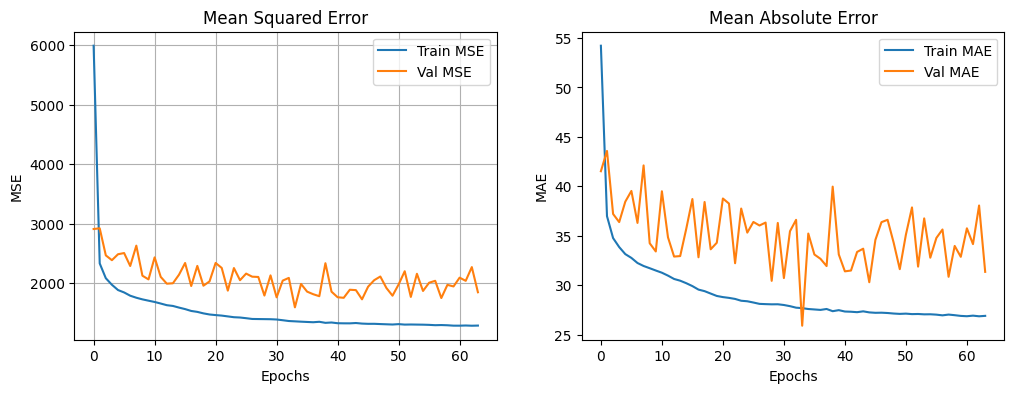

Validation Loss = 1596.1930
least val_loss = 1596.1930
New best_nn_model_config: {'num_nodes': 32, 'dropout_prob': 0, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 150}
32 nodes | dropout: 0 | lr: 0.001 | batch size: 64
Final train loss (MSE): 1315.1135, MAE: 27.1283
Final val loss (MSE): 1951.1632, MAE: 34.2353


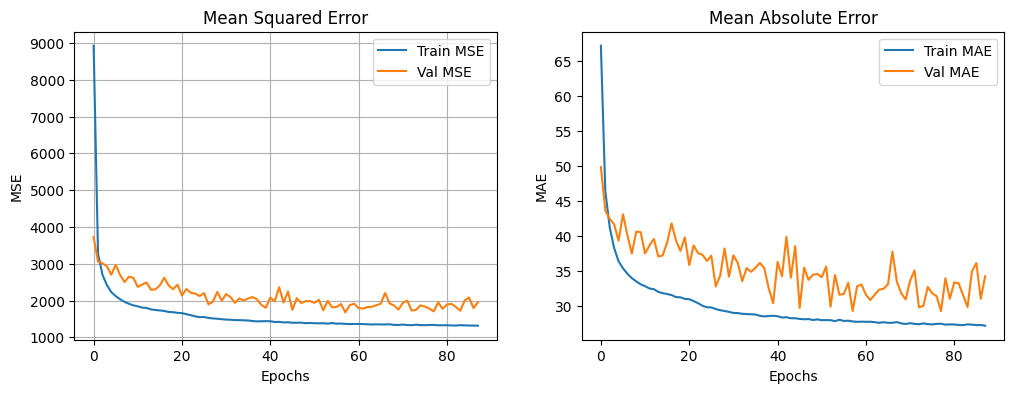

Validation Loss = 1679.2782
32 nodes | dropout: 0 | lr: 0.001 | batch size: 128
Final train loss (MSE): 1330.8121, MAE: 27.1941
Final val loss (MSE): 1874.9467, MAE: 33.0232


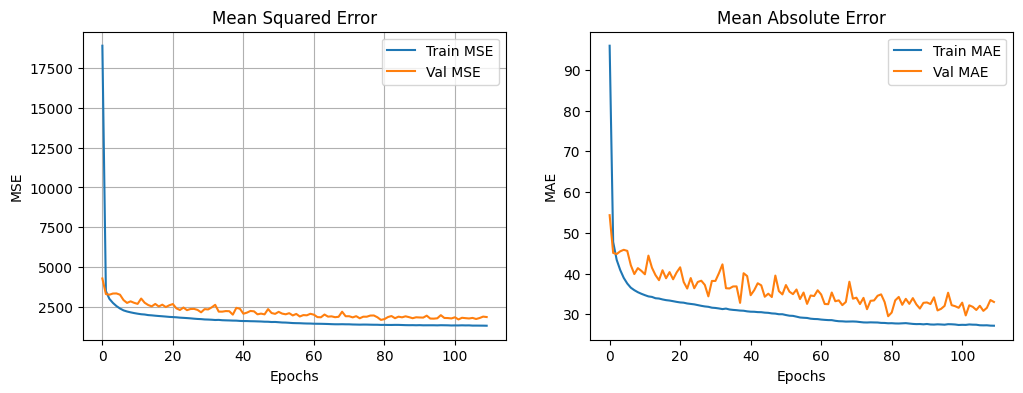

Validation Loss = 1697.9082
32 nodes | dropout: 0.2 | lr: 0.01 | batch size: 32
Final train loss (MSE): 2591.6328, MAE: 38.5264
Final val loss (MSE): 2472.3325, MAE: 37.4737


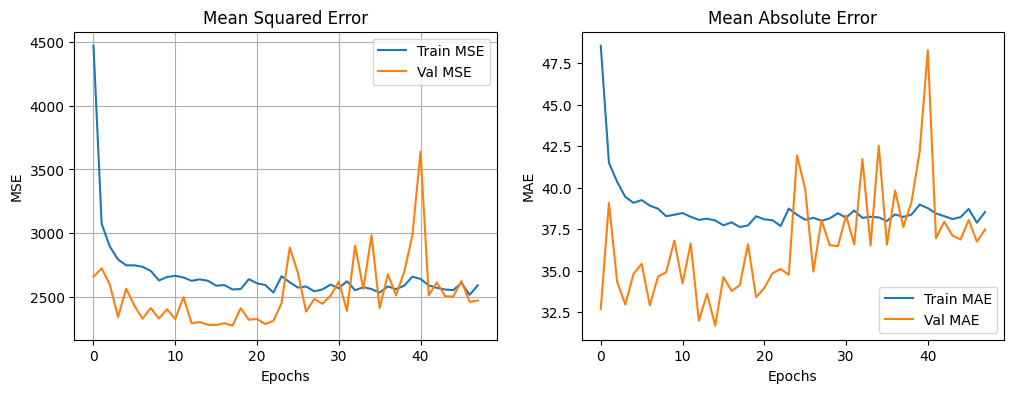

Validation Loss = 2274.7996
32 nodes | dropout: 0.2 | lr: 0.01 | batch size: 64
Final train loss (MSE): 2227.2463, MAE: 35.5467
Final val loss (MSE): 2094.1548, MAE: 34.3936


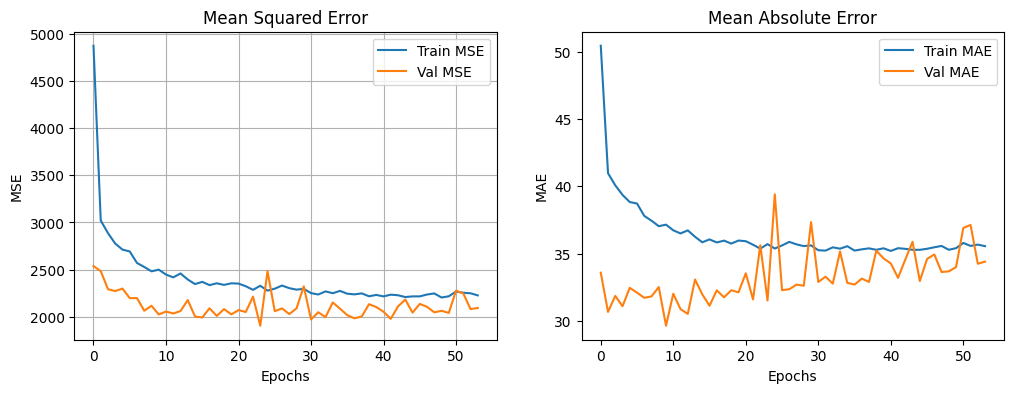

Validation Loss = 1905.7858
32 nodes | dropout: 0.2 | lr: 0.01 | batch size: 128
Final train loss (MSE): 2140.1843, MAE: 34.4595
Final val loss (MSE): 2001.0481, MAE: 32.3751


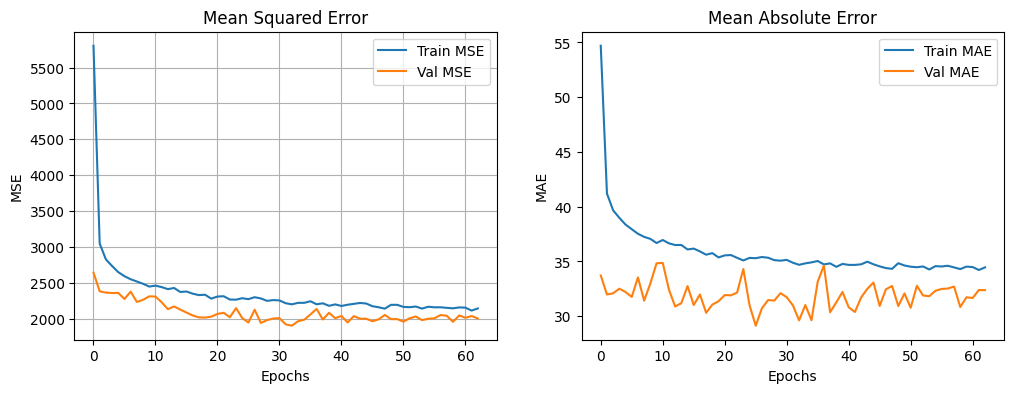

Validation Loss = 1899.2920
32 nodes | dropout: 0.2 | lr: 0.005 | batch size: 32
Final train loss (MSE): 2176.3843, MAE: 35.0857
Final val loss (MSE): 2199.9338, MAE: 35.5946


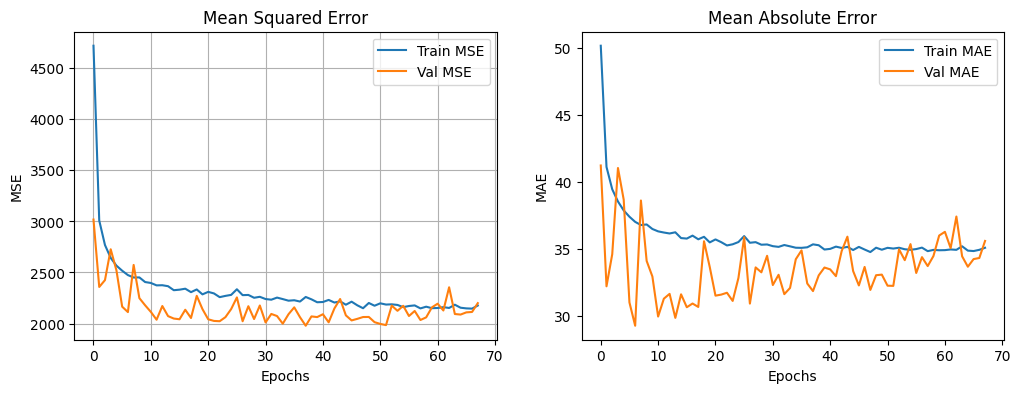

Validation Loss = 1978.7507
32 nodes | dropout: 0.2 | lr: 0.005 | batch size: 64
Final train loss (MSE): 2107.2014, MAE: 34.0525
Final val loss (MSE): 2031.9369, MAE: 32.0996


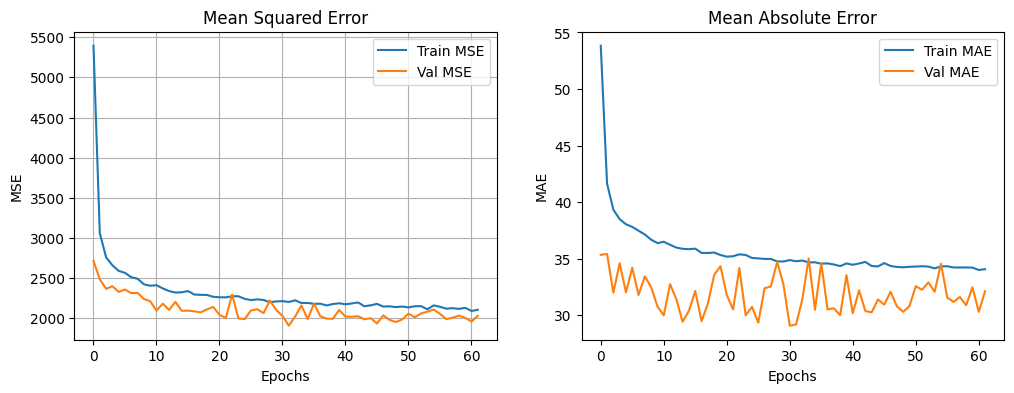

Validation Loss = 1908.7019
32 nodes | dropout: 0.2 | lr: 0.005 | batch size: 128
Final train loss (MSE): 2158.8762, MAE: 34.5718
Final val loss (MSE): 1947.1428, MAE: 31.7361


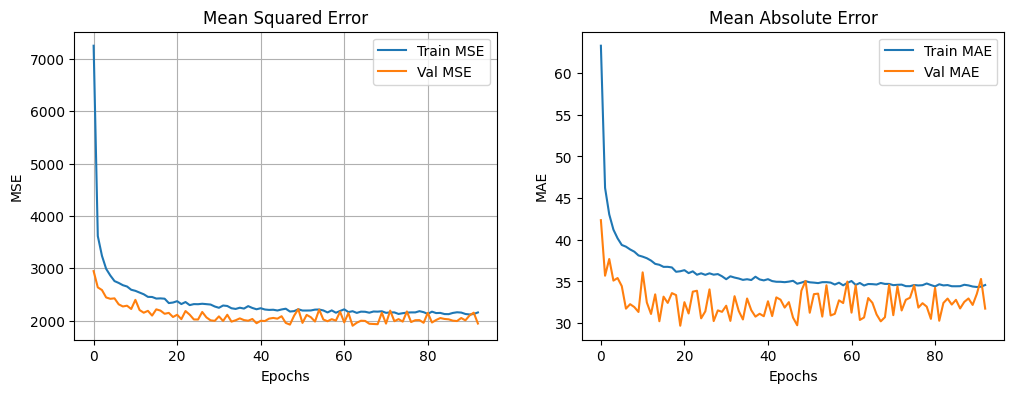

Validation Loss = 1905.4503
32 nodes | dropout: 0.2 | lr: 0.001 | batch size: 32
Final train loss (MSE): 1982.5350, MAE: 33.0220
Final val loss (MSE): 1857.3077, MAE: 29.5640


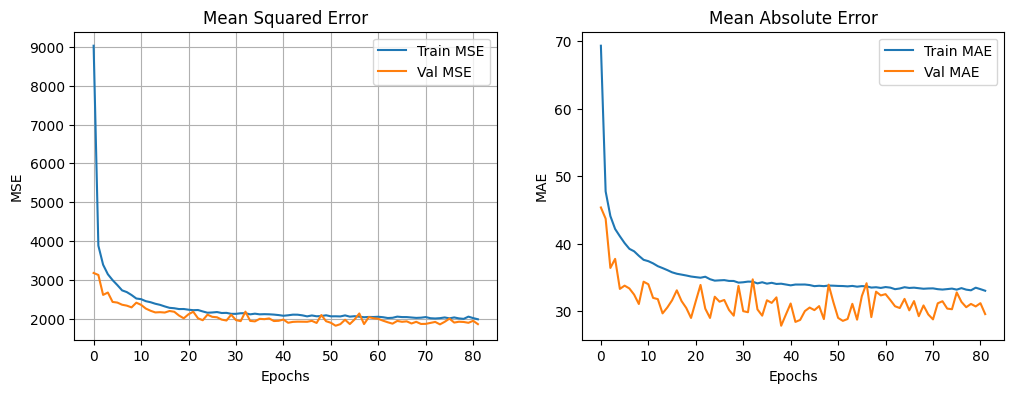

Validation Loss = 1816.3922
32 nodes | dropout: 0.2 | lr: 0.001 | batch size: 64
Final train loss (MSE): 2039.6796, MAE: 33.4359
Final val loss (MSE): 2059.7490, MAE: 32.7457


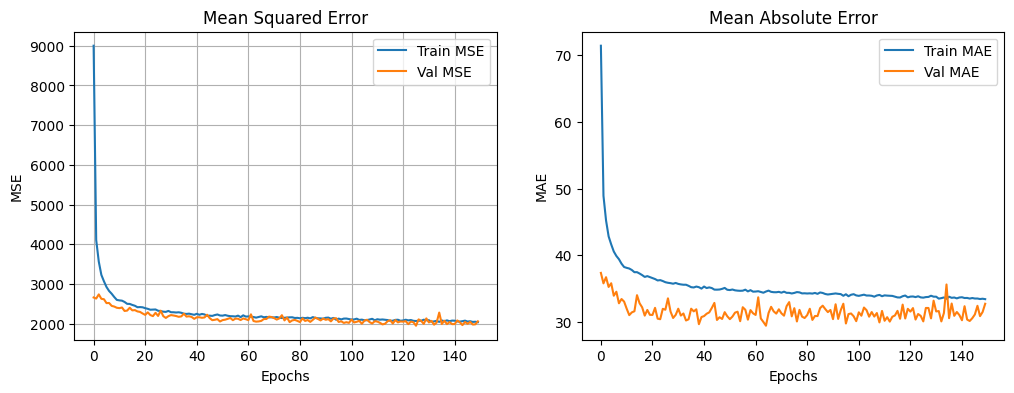

Validation Loss = 2059.7500
32 nodes | dropout: 0.2 | lr: 0.001 | batch size: 128
Final train loss (MSE): 2059.1626, MAE: 33.7216
Final val loss (MSE): 1957.6589, MAE: 31.7069


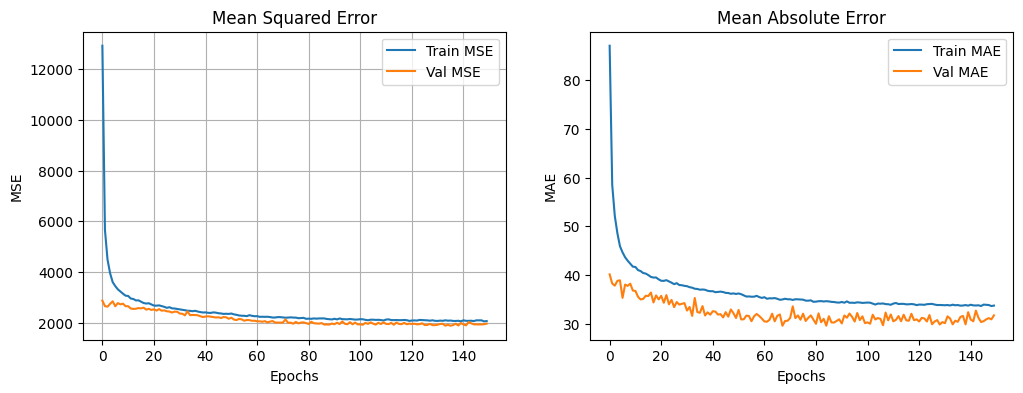

Validation Loss = 1957.6588
64 nodes | dropout: 0 | lr: 0.01 | batch size: 32
Final train loss (MSE): 1455.7877, MAE: 28.2720
Final val loss (MSE): 1925.5605, MAE: 29.9486


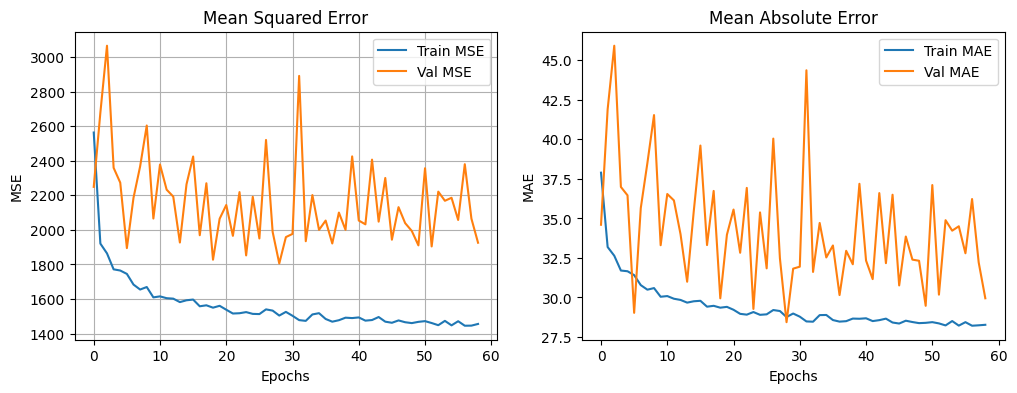

Validation Loss = 1805.6292
64 nodes | dropout: 0 | lr: 0.01 | batch size: 64
Final train loss (MSE): 1293.7091, MAE: 26.7627
Final val loss (MSE): 1790.8265, MAE: 30.1237


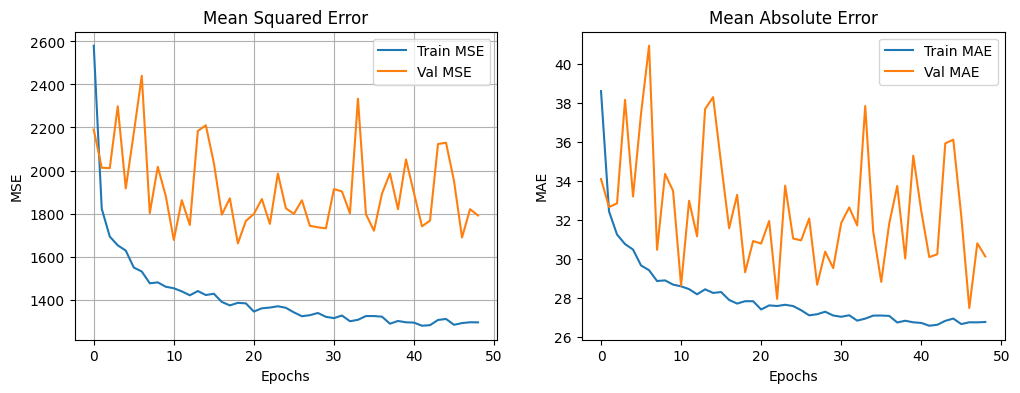

Validation Loss = 1660.9319
64 nodes | dropout: 0 | lr: 0.01 | batch size: 128
Final train loss (MSE): 1131.2812, MAE: 25.0262
Final val loss (MSE): 2016.1128, MAE: 32.2782


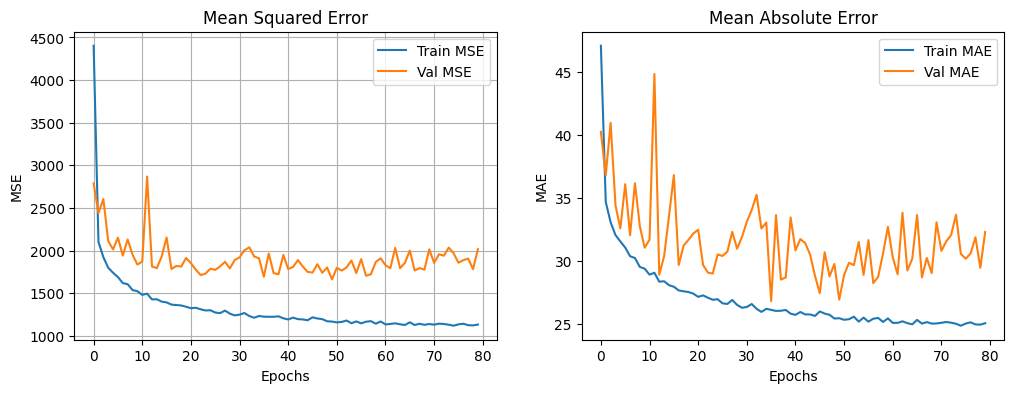

Validation Loss = 1660.8977
64 nodes | dropout: 0 | lr: 0.005 | batch size: 32
Final train loss (MSE): 1211.9982, MAE: 25.8636
Final val loss (MSE): 1782.7792, MAE: 29.3173


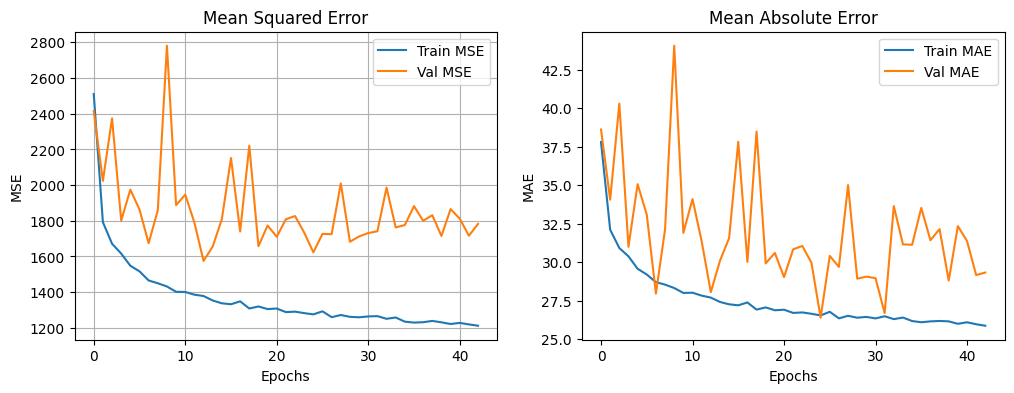

Validation Loss = 1574.8250
least val_loss = 1574.8250
New best_nn_model_config: {'num_nodes': 64, 'dropout_prob': 0, 'learning_rate': 0.005, 'batch_size': 32, 'epochs': 150}
64 nodes | dropout: 0 | lr: 0.005 | batch size: 64
Final train loss (MSE): 1184.9301, MAE: 25.6815
Final val loss (MSE): 1716.1831, MAE: 28.1766


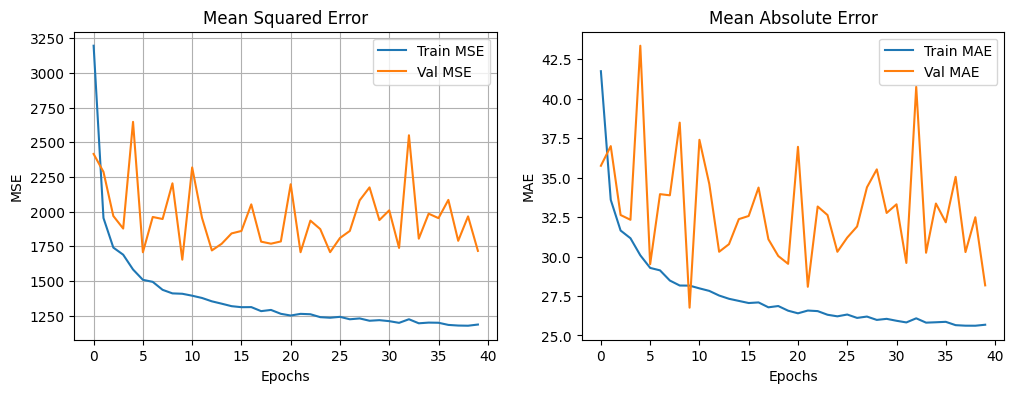

Validation Loss = 1652.8883
64 nodes | dropout: 0 | lr: 0.005 | batch size: 128
Final train loss (MSE): 1132.9453, MAE: 25.1035
Final val loss (MSE): 1932.9454, MAE: 33.0683


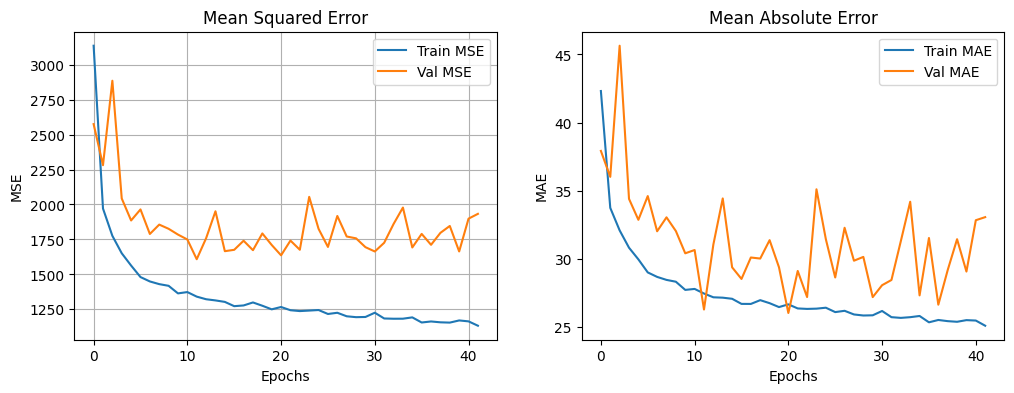

Validation Loss = 1608.5190
64 nodes | dropout: 0 | lr: 0.001 | batch size: 32
Final train loss (MSE): 1049.2305, MAE: 24.1553
Final val loss (MSE): 1731.8507, MAE: 30.3811


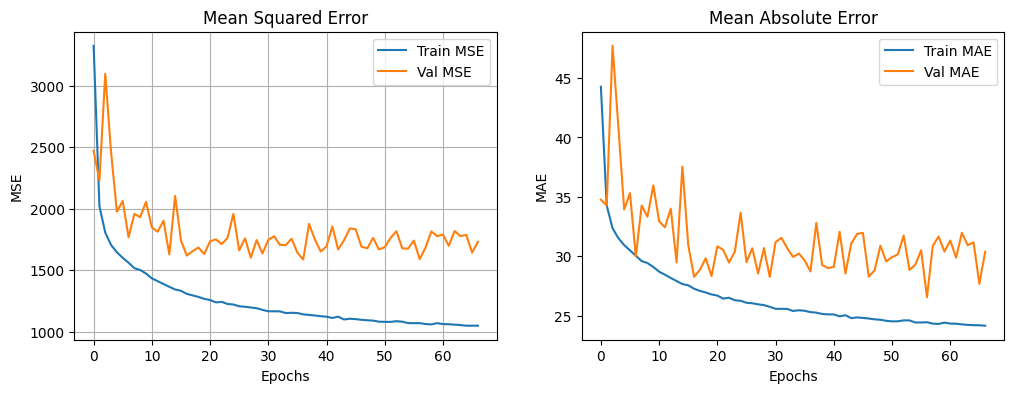

Validation Loss = 1588.0508
64 nodes | dropout: 0 | lr: 0.001 | batch size: 64
Final train loss (MSE): 1135.6372, MAE: 25.3099
Final val loss (MSE): 2360.6394, MAE: 37.5419


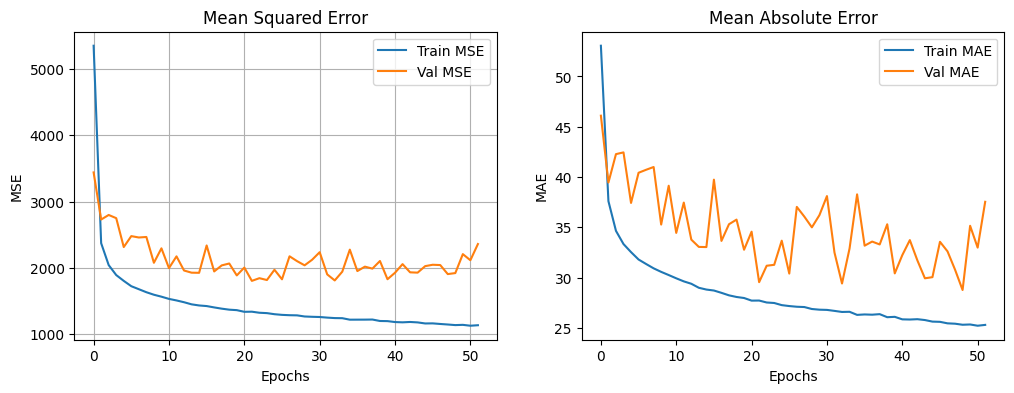

Validation Loss = 1804.7676
64 nodes | dropout: 0 | lr: 0.001 | batch size: 128
Final train loss (MSE): 1195.3474, MAE: 25.9020
Final val loss (MSE): 1809.0920, MAE: 30.2975


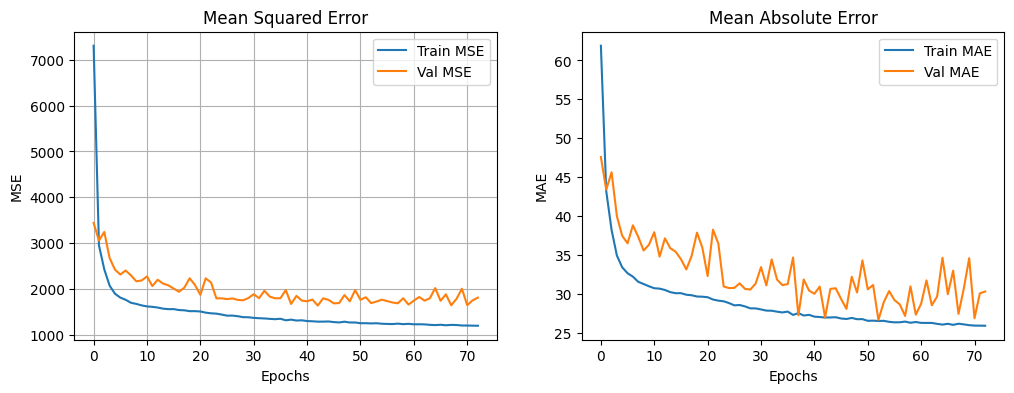

Validation Loss = 1635.4786
64 nodes | dropout: 0.2 | lr: 0.01 | batch size: 32
Final train loss (MSE): 2482.3010, MAE: 37.5916
Final val loss (MSE): 2400.0305, MAE: 36.5646


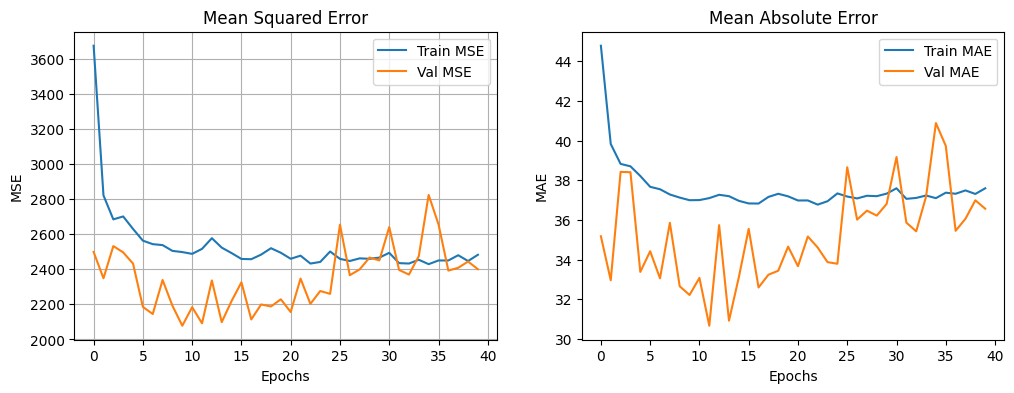

Validation Loss = 2077.9119
64 nodes | dropout: 0.2 | lr: 0.01 | batch size: 64
Final train loss (MSE): 2204.8511, MAE: 35.1442
Final val loss (MSE): 1998.0109, MAE: 32.4534


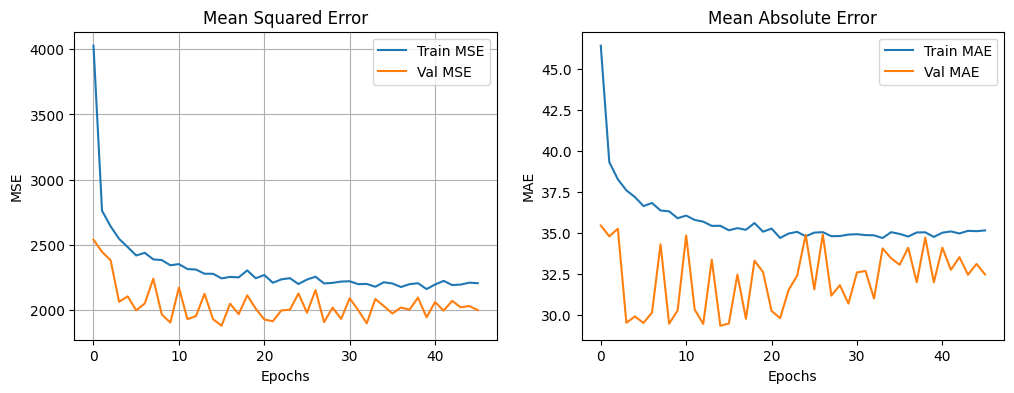

Validation Loss = 1878.8544
64 nodes | dropout: 0.2 | lr: 0.01 | batch size: 128
Final train loss (MSE): 1869.9607, MAE: 32.4480
Final val loss (MSE): 1976.8240, MAE: 32.7528


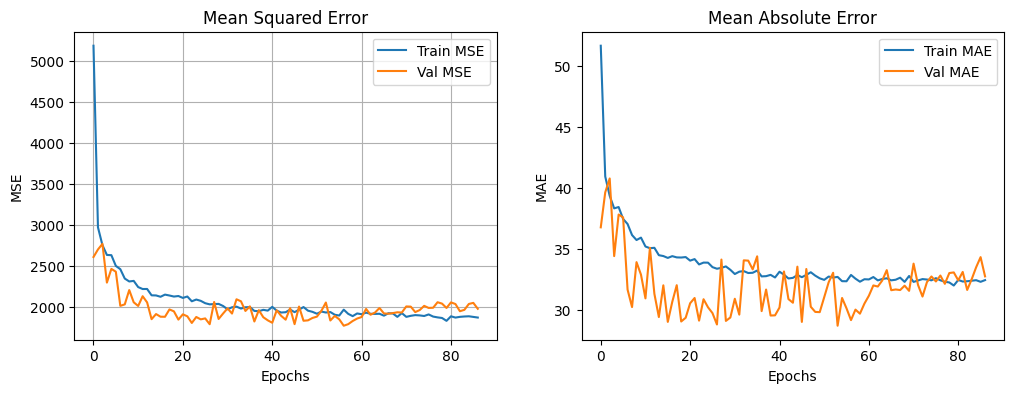

Validation Loss = 1770.2438
64 nodes | dropout: 0.2 | lr: 0.005 | batch size: 32
Final train loss (MSE): 1908.6698, MAE: 32.8403
Final val loss (MSE): 1824.9375, MAE: 31.0298


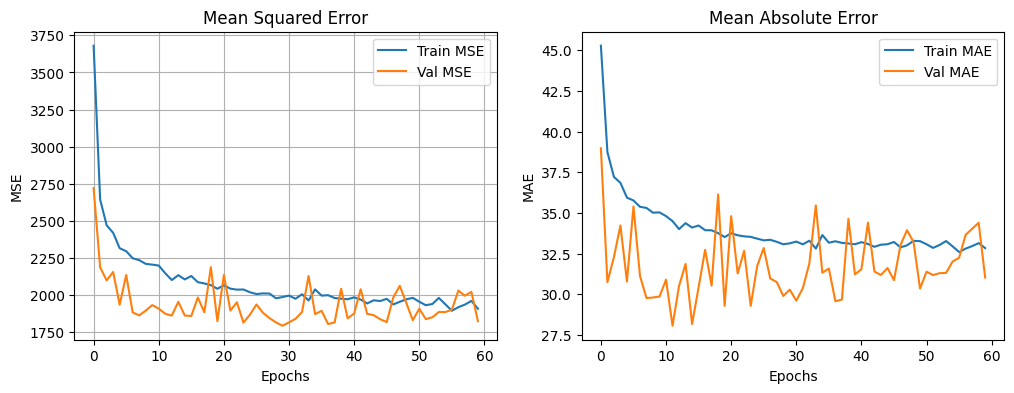

Validation Loss = 1794.2493
64 nodes | dropout: 0.2 | lr: 0.005 | batch size: 64
Final train loss (MSE): 1773.8425, MAE: 31.2783
Final val loss (MSE): 1880.1926, MAE: 30.5139


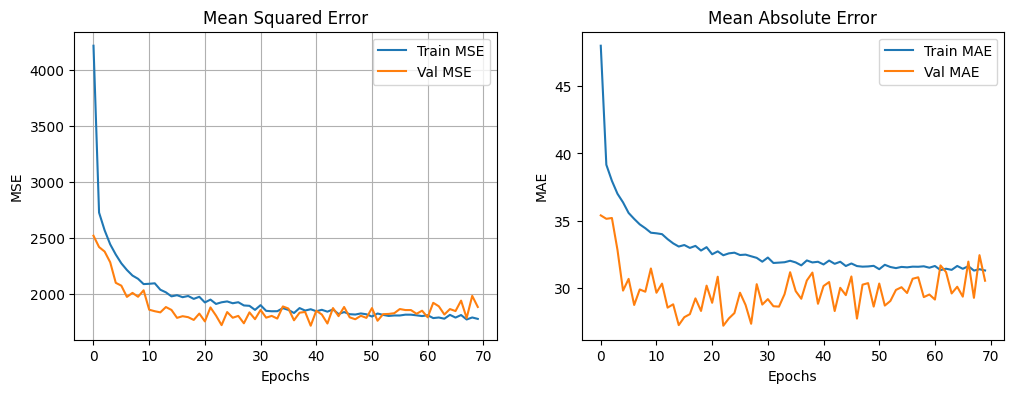

Validation Loss = 1712.7841
64 nodes | dropout: 0.2 | lr: 0.005 | batch size: 128
Final train loss (MSE): 1791.1534, MAE: 31.3607
Final val loss (MSE): 1820.3834, MAE: 28.2664


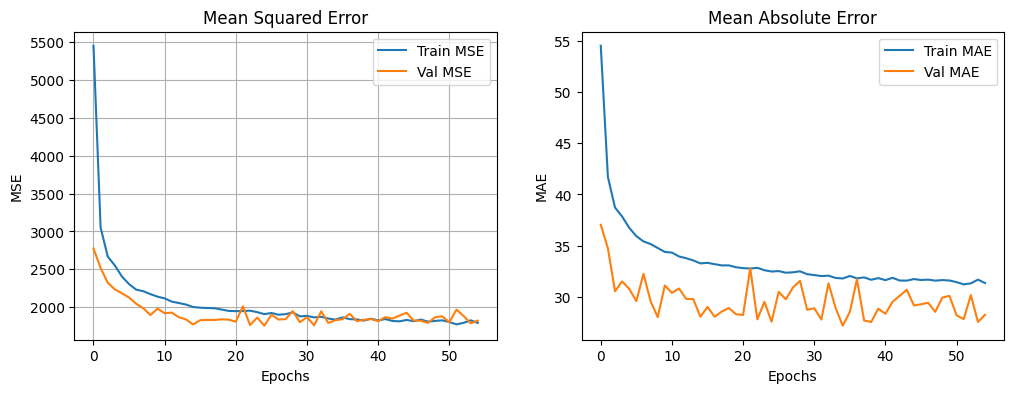

Validation Loss = 1753.6947
64 nodes | dropout: 0.2 | lr: 0.001 | batch size: 32
Final train loss (MSE): 1616.4716, MAE: 29.8435
Final val loss (MSE): 1751.2936, MAE: 27.7628


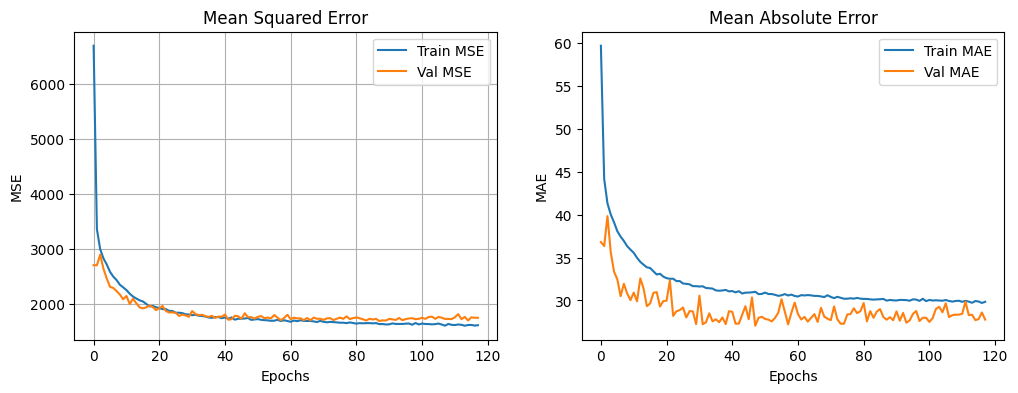

Validation Loss = 1692.7839
64 nodes | dropout: 0.2 | lr: 0.001 | batch size: 64
Final train loss (MSE): 1594.0930, MAE: 29.5380
Final val loss (MSE): 1673.5165, MAE: 27.0869


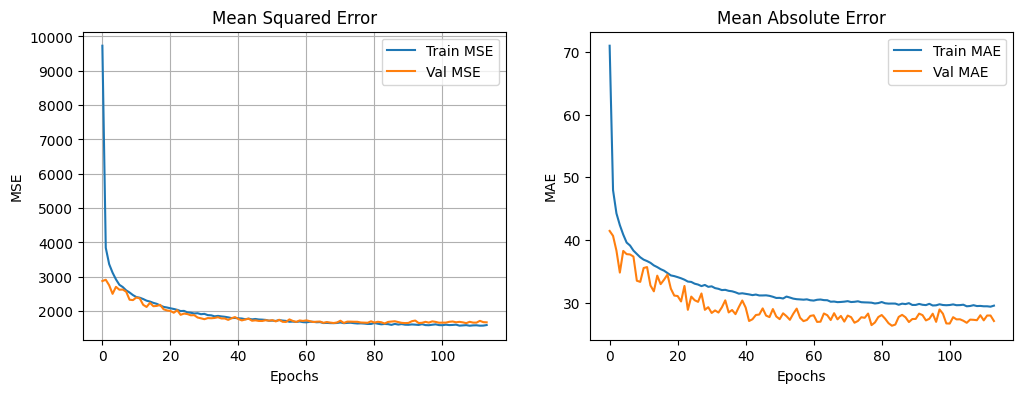

Validation Loss = 1639.3268
64 nodes | dropout: 0.2 | lr: 0.001 | batch size: 128
Final train loss (MSE): 1602.8497, MAE: 29.7129
Final val loss (MSE): 1677.9265, MAE: 27.8221


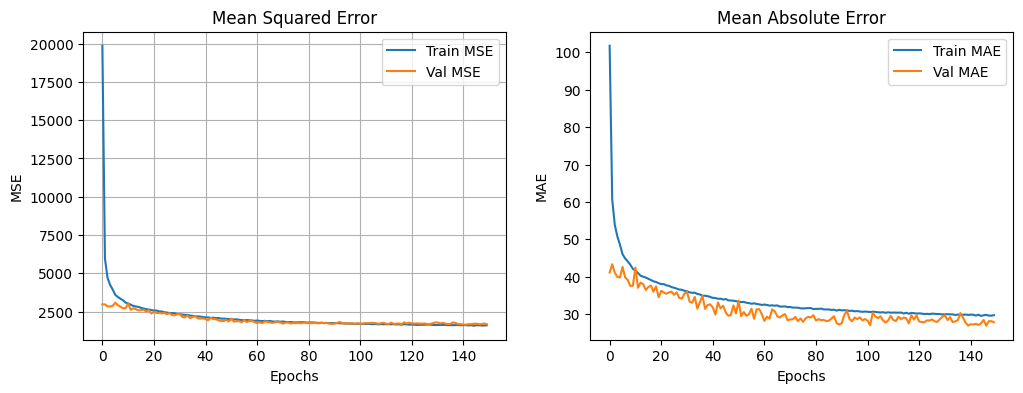

Validation Loss = 1677.9263


In [ ]:
least_val_loss = float('inf')
least_loss_model = None
best_nn_model_config = None
epochs = 150

early_stop = EarlyStopping(
    monitor='val_loss',          # metric to monitor
    patience=30,                 # how many epochs to wait
    restore_best_weights=True,   # revert to best weights
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',          # metric to monitor
    factor=0.5,                  # reduce learning rate by this factor
    patience=10,                 # wait 10 epochs without improvement
    min_lr=1e-6,                 # lower bound of lr
    verbose=1
)

for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.01, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"{num_nodes} nodes | dropout: {dropout_prob} | lr: {lr} | batch size: {batch_size}")

                # convert validation to numpy if DataFrame
                x_valid_arr = x_valid.values if hasattr(x_valid, "values") else x_valid
                y_valid_arr = y_valid.values if hasattr(y_valid, "values") else y_valid

                model, history = train_model(
                    x_train_res_df.values, y_train_res_df.values,
                    x_valid_arr, y_valid_arr,
                    num_nodes, dropout_prob, lr, batch_size, epochs,
                    callbacks=[early_stop, reduce_lr]
                )

                plot_history(history)
                val_loss = model.evaluate(x_valid_arr, y_valid_arr, verbose=0)[0]
                print(f"Validation Loss = {val_loss:.4f}")

                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model
                    print(f"least val_loss = {least_val_loss:.4f}")
                    best_nn_model_config = {
                        'num_nodes': num_nodes,
                        'dropout_prob': dropout_prob,
                        'learning_rate': lr,
                        'batch_size': batch_size,
                        'epochs': epochs
                    }

                    print(f"New best_nn_model_config: {best_nn_model_config}")

In [202]:
y_pred_nn

array([[58.559673 , 60.257652 , 50.134106 , ..., 69.98813  , 31.128603 ,
        15.548875 ],
       [44.199635 , 27.345322 , 26.643772 , ..., 52.595715 , 54.305607 ,
        46.489933 ],
       [58.34425  , 59.257305 , 55.910774 , ..., 16.621649 ,  8.590973 ,
        11.454109 ],
       ...,
       [46.357807 , 45.45873  , 44.256596 , ...,  1.0918108,  6.627653 ,
        55.081223 ],
       [51.732037 , 48.558582 , 40.204018 , ..., 57.563744 , 36.97205  ,
         8.715636 ],
       [25.940159 , 40.78663  , 53.934273 , ..., 19.812853 , 31.540907 ,
        23.330967 ]], dtype=float32)

SAVE NEURAL NETWORK MODEL USING OVERSAMPLING SMOGN


In [199]:
import json
least_loss_model.save("best_nn_smogn_model.keras")

with open("best_nn_smogn_model_config.json", "w") as f:
    json.dump(best_nn_model_config, f, indent = 4)

In [214]:
# Simulate 24-hour energy consumption + extra features for prediction
test_data = [7, 13, 15, 17, 19, 15, 14, 17, 20, 22, 25, 30, 24, 26, 32, 40, 35, 37, 47, 20, 15, 10, 8, 6]

test_lag1 = [0, 6, 2, 2, 2, -4, -1, 3, 3, 2, 3, 5, -6, 2, 6, 8, -5, 2, 10, -27, -5, -5, -2, -2, 114, 2025, 3, 10, 7]

# Build columns properly
columns = [f"Lag1_{i}" for i in range(24)] + ["Lag1_Total", "Year", "Day of Week", "Month", "Individual code"]

# Ensure the test vector length matches the columns length (trim or pad with zeros)
if len(test_lag1) > len(columns):
    test_lag1 = test_lag1[:len(columns)]
elif len(test_lag1) < len(columns):
    test_lag1 = test_lag1 + [0] * (len(columns) - len(test_lag1))

test_lag1_df = pd.DataFrame([test_lag1], columns=columns).astype(float)

test_data_pred = least_loss_model.predict(test_lag1_df)
print(test_data_pred)

1/1 [==============================] - 0s 24ms/step
[[12.251836  18.153023  26.507797  25.604942  24.281136  23.779789
  22.281843  31.471132  25.608637  18.38709   23.84989   24.708683
  22.027287  12.96295   23.623901  30.749046  17.903027  28.552746
  29.398924   9.373554   7.39264    1.9763008 -2.2060828 13.500251 ]]
